# SEC EDGAR 10-Q Financial Report Analyzer

This notebook fetches and analyzes **10-Q quarterly financial reports** from the SEC EDGAR API.

**What it does:**
1. Searches for a company by name or CIK number
2. Retrieves their most recent 10-Q filings
3. Extracts key financial data (revenue, net income, assets, etc.)
4. Visualizes financial trends across quarters
5. Provides a summary analysis

> **Note:** The SEC EDGAR API requires a valid `User-Agent` header with your name and email. No API key is needed.

In [ ]:
# Install dependencies
!pip install requests pandas matplotlib plotly -q

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import time
from datetime import datetime

# SEC EDGAR requires a User-Agent header with contact info
HEADERS = {
    "User-Agent": "SECAnalyzer/1.0 (research@example.com)",
    "Accept": "application/json"
}

BASE_URL = "https://efts.sec.gov/LATEST"
DATA_URL = "https://data.sec.gov"

print("✅ Libraries loaded and SEC EDGAR API configured")

✅ Libraries loaded and SEC EDGAR API configured


## 1. Company Search

Search for a company by name to find their CIK (Central Index Key) number, which is required for all EDGAR lookups.

In [ ]:
def search_company(query, max_results=10):
    """Search SEC EDGAR for companies by name or ticker."""
    # Use the company tickers JSON for lookup
    tickers_url = "https://www.sec.gov/files/company_tickers.json"
    tickers_resp = requests.get(tickers_url, headers=HEADERS)
    tickers_resp.raise_for_status()
    tickers_data = tickers_resp.json()

    results = []
    query_lower = query.lower()
    for key, entry in tickers_data.items():
        name = entry.get("title", "").lower()
        ticker = entry.get("ticker", "").lower()
        if query_lower in name or query_lower == ticker:
            results.append({
                "cik": str(entry["cik_str"]).zfill(10),
                "ticker": entry.get("ticker", "N/A"),
                "name": entry.get("title", "Unknown")
            })
        if len(results) >= max_results:
            break

    return results


# 🔍 Search for a company — change this to any company name or ticker
SEARCH_QUERY = "Apple"

results = search_company(SEARCH_QUERY)

if results:
    print(f"Found {len(results)} result(s) for '{SEARCH_QUERY}':\n")
    for i, r in enumerate(results):
        print(f"  [{i}] {r['name']} (Ticker: {r['ticker']}, CIK: {r['cik']})")
else:
    print(f"No results found for '{SEARCH_QUERY}'. Try a different search term.")

Found 7 result(s) for 'Apple':

  [0] Apple Inc. (Ticker: AAPL, CIK: 0000320193)
  [1] Apple Hospitality REIT, Inc. (Ticker: APLE, CIK: 0001418121)
  [2] MAUI LAND & PINEAPPLE CO INC (Ticker: MLP, CIK: 0000063330)
  [3] Apple iSports Group, Inc. (Ticker: AAPI, CIK: 0001134982)
  [4] Pineapple Financial Inc. (Ticker: PAPL, CIK: 0001938109)
  [5] PINEAPPLE EXPRESS CANNABIS Co (Ticker: PNXP, CIK: 0001710495)
  [6] PINEAPPLE, INC. (Ticker: PNPL, CIK: 0001654672)


## 2. Select Company & Fetch 10-Q Filings

Select a company from the search results and retrieve their 10-Q filing history.

In [ ]:
# Select the company index from search results above (default: 0 = first result)
SELECTED_INDEX = 0

selected = results[SELECTED_INDEX]
CIK = selected["cik"]
COMPANY_NAME = selected["name"]
TICKER = selected["ticker"]

print(f"Selected: {COMPANY_NAME} (Ticker: {TICKER}, CIK: {CIK})")
print("-" * 60)

def get_10q_filings(cik, count=20):
    """Fetch recent 10-Q filings for a given CIK."""
    url = f"{DATA_URL}/submissions/CIK{cik}.json"
    resp = requests.get(url, headers=HEADERS)
    resp.raise_for_status()
    data = resp.json()

    recent = data.get("filings", {}).get("recent", {})
    forms = recent.get("form", [])
    dates = recent.get("filingDate", [])
    accessions = recent.get("accessionNumber", [])
    primary_docs = recent.get("primaryDocument", [])

    filings = []
    for i, form in enumerate(forms):
        if form == "10-Q":
            filings.append({
                "form": form,
                "filing_date": dates[i],
                "accession": accessions[i],
                "primary_doc": primary_docs[i],
                "accession_clean": accessions[i].replace("-", "")
            })
        if len(filings) >= count:
            break

    return filings, data

filings, company_data = get_10q_filings(CIK)

print(f"\nFound {len(filings)} recent 10-Q filings:\n")
for f in filings[:10]:
    print(f"  📄 {f['filing_date']}  |  Accession: {f['accession']}")

Selected: Apple Inc. (Ticker: AAPL, CIK: 0000320193)
------------------------------------------------------------

Found 20 recent 10-Q filings:

  📄 2026-01-30  |  Accession: 0000320193-26-000006
  📄 2025-08-01  |  Accession: 0000320193-25-000073
  📄 2025-05-02  |  Accession: 0000320193-25-000057
  📄 2025-01-31  |  Accession: 0000320193-25-000008
  📄 2024-08-02  |  Accession: 0000320193-24-000081
  📄 2024-05-03  |  Accession: 0000320193-24-000069
  📄 2024-02-02  |  Accession: 0000320193-24-000006
  📄 2023-08-04  |  Accession: 0000320193-23-000077
  📄 2023-05-05  |  Accession: 0000320193-23-000064
  📄 2023-02-03  |  Accession: 0000320193-23-000006


## 3. Extract Financial Data from Company Facts

The SEC EDGAR API provides structured financial data through the "Company Facts" endpoint, which contains XBRL-tagged financial metrics from all filings.

In [ ]:
def get_company_facts(cik):
    """Fetch all XBRL financial facts for a company."""
    url = f"{DATA_URL}/api/xbrl/companyfacts/CIK{cik}.json"
    resp = requests.get(url, headers=HEADERS)
    resp.raise_for_status()
    return resp.json()

facts = get_company_facts(CIK)

# Key financial metrics to extract from 10-Q filings
METRICS = {
    "Revenues": ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax",
                  "SalesRevenueNet", "RevenueFromContractWithCustomerIncludingAssessedTax"],
    "NetIncome": ["NetIncomeLoss", "ProfitLoss"],
    "TotalAssets": ["Assets"],
    "TotalLiabilities": ["Liabilities"],
    "StockholdersEquity": ["StockholdersEquity", "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest"],
    "CashAndEquivalents": ["CashAndCashEquivalentsAtCarryingValue", "CashCashEquivalentsAndShortTermInvestments"],
    "OperatingIncome": ["OperatingIncomeLoss"],
    "EarningsPerShare": ["EarningsPerShareBasic"],
    "GrossProfit": ["GrossProfit"],
}

def extract_quarterly_data(facts_data, metric_names, form_filter="10-Q"):
    """Extract quarterly financial data for a given metric from company facts."""
    us_gaap = facts_data.get("facts", {}).get("us-gaap", {})

    for metric_name in metric_names:
        if metric_name in us_gaap:
            units = us_gaap[metric_name].get("units", {})
            # Try USD first, then USD/shares for per-share metrics
            for unit_key in ["USD", "USD/shares"]:
                if unit_key in units:
                    entries = units[unit_key]
                    quarterly = []
                    for e in entries:
                        if e.get("form") == form_filter and e.get("fp") in ["Q1", "Q2", "Q3", "Q4"]:
                            quarterly.append({
                                "period": e.get("end"),
                                "value": e.get("val"),
                                "fiscal_period": e.get("fp"),
                                "fiscal_year": e.get("fy"),
                                "filed": e.get("filed"),
                                "frame": e.get("frame", "")
                            })
                    if quarterly:
                        return quarterly, metric_name
    return [], None

# Extract all metrics
financial_data = {}
print(f"📊 Extracting financial data for {COMPANY_NAME}...\n")

for display_name, metric_candidates in METRICS.items():
    data, found_metric = extract_quarterly_data(facts, metric_candidates)
    if data:
        # Deduplicate by period — keep the most recent filing
        seen = {}
        for d in data:
            key = d["period"]
            if key not in seen or d["filed"] > seen[key]["filed"]:
                seen[key] = d
        deduped = sorted(seen.values(), key=lambda x: x["period"])
        financial_data[display_name] = deduped
        print(f"  ✅ {display_name}: {len(deduped)} quarters (via {found_metric})")
    else:
        print(f"  ❌ {display_name}: not found")

print(f"\n{'='*60}")
print(f"Successfully extracted {len(financial_data)} metrics")

📊 Extracting financial data for Apple Inc....

  ✅ Revenues: 25 quarters (via RevenueFromContractWithCustomerExcludingAssessedTax)
  ✅ NetIncome: 53 quarters (via NetIncomeLoss)
  ✅ TotalAssets: 68 quarters (via Assets)
  ✅ TotalLiabilities: 68 quarters (via Liabilities)
  ✅ StockholdersEquity: 68 quarters (via StockholdersEquity)
  ✅ CashAndEquivalents: 72 quarters (via CashAndCashEquivalentsAtCarryingValue)
  ✅ OperatingIncome: 53 quarters (via OperatingIncomeLoss)
  ✅ EarningsPerShare: 53 quarters (via EarningsPerShareBasic)
  ✅ GrossProfit: 53 quarters (via GrossProfit)

Successfully extracted 9 metrics


## 4. Financial Data Table

View the extracted quarterly financial data in a structured table, focusing on the most recent quarters.

In [ ]:
# Build a consolidated DataFrame of recent quarterly data
NUM_QUARTERS = 12  # Show last 12 quarters (3 years)

all_rows = []
for metric_name, entries in financial_data.items():
    recent = entries[-NUM_QUARTERS:]
    for e in recent:
        all_rows.append({
            "Metric": metric_name,
            "Period End": e["period"],
            "Fiscal Year": e["fiscal_year"],
            "Fiscal Quarter": e["fiscal_period"],
            "Value": e["value"],
            "Filed Date": e["filed"]
        })

df = pd.DataFrame(all_rows)

# Create a pivot table for a cleaner view
if not df.empty:
    df["Period Label"] = df["Fiscal Quarter"].astype(str) + " " + df["Fiscal Year"].astype(str)
    pivot = df.pivot_table(index="Metric", columns="Period End", values="Value", aggfunc="last")
    pivot = pivot[sorted(pivot.columns)[-NUM_QUARTERS:]]

    # Format large numbers
    def format_val(x):
        if pd.isna(x):
            return "-"
        if abs(x) >= 1e9:
            return f"${x/1e9:.2f}B"
        elif abs(x) >= 1e6:
            return f"${x/1e6:.1f}M"
        elif abs(x) >= 1e3:
            return f"${x/1e3:.1f}K"
        else:
            return f"${x:.2f}"

    display_pivot = pivot.map(format_val)
    print(f"📋 {COMPANY_NAME} — Quarterly Financial Data (Last {NUM_QUARTERS} Quarters)\n")
    print(display_pivot.to_string())
else:
    print("No quarterly data available to display.")

📋 Apple Inc. — Quarterly Financial Data (Last 12 Quarters)

Period End         2023-04-01 2023-07-01 2023-09-30 2023-12-30 2024-03-30 2024-06-29 2024-09-28 2024-12-28 2025-03-29 2025-06-28 2025-09-27 2025-12-27
Metric                                                                                                                                                
CashAndEquivalents    $24.69B    $28.41B    $29.96B    $40.76B    $32.70B    $25.57B    $29.94B    $30.30B    $28.16B    $36.27B    $35.93B    $45.32B
EarningsPerShare        $3.42      $4.69          -      $2.19      $3.72      $5.13          -      $2.41      $4.06      $5.64          -      $2.85
GrossProfit           $92.31B   $128.72B          -    $54.85B    $97.13B   $136.80B          -    $58.27B   $103.14B   $146.86B          -    $69.23B
NetIncome             $54.16B    $74.04B          -    $33.92B    $57.55B    $79.00B          -    $36.33B    $61.11B    $84.54B          -    $42.10B
OperatingIncome       $64.33B    $

/tmp/ipykernel_406/1001846647.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display_pivot = pivot.applymap(format_val)


## 5. Revenue & Profitability Trend Charts

Visualize key financial metrics over time to identify trends in the company's performance.

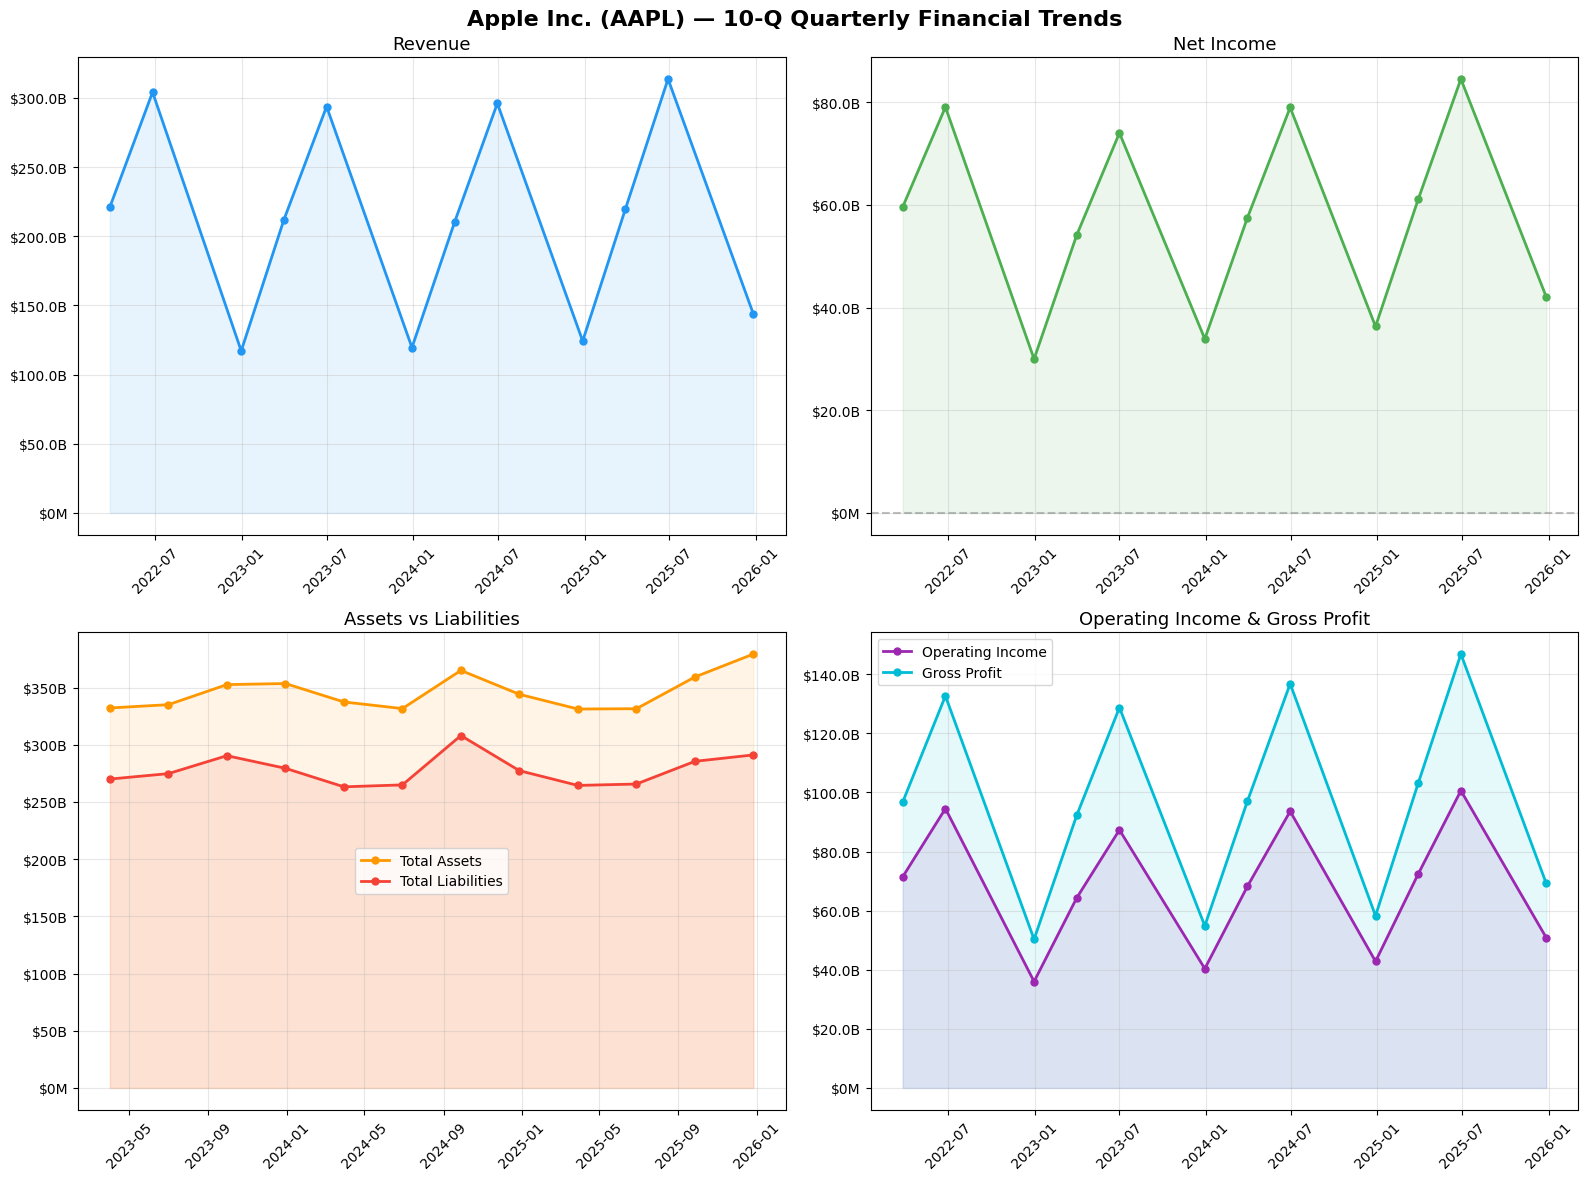

In [ ]:
def plot_metric(metric_name, color, ax, label=None):
    """Plot a single metric on the given axes."""
    if metric_name not in financial_data:
        return False
    entries = financial_data[metric_name][-NUM_QUARTERS:]
    dates = [datetime.strptime(e["period"], "%Y-%m-%d") for e in entries]
    values = [e["value"] for e in entries]
    ax.plot(dates, values, marker="o", color=color, linewidth=2, markersize=5, label=label or metric_name)
    ax.fill_between(dates, values, alpha=0.1, color=color)
    return True

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"{COMPANY_NAME} ({TICKER}) — 10-Q Quarterly Financial Trends", fontsize=16, fontweight="bold")

# Revenue
ax = axes[0, 0]
if plot_metric("Revenues", "#2196F3", ax):
    ax.set_title("Revenue", fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e9:.1f}B" if x >= 1e9 else f"${x/1e6:.0f}M"))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

# Net Income
ax = axes[0, 1]
if plot_metric("NetIncome", "#4CAF50", ax):
    ax.set_title("Net Income", fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e9:.1f}B" if abs(x) >= 1e9 else f"${x/1e6:.0f}M"))
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

# Total Assets vs Liabilities
ax = axes[1, 0]
has_assets = plot_metric("TotalAssets", "#FF9800", ax, label="Total Assets")
has_liab = plot_metric("TotalLiabilities", "#F44336", ax, label="Total Liabilities")
if has_assets or has_liab:
    ax.set_title("Assets vs Liabilities", fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e9:.0f}B" if x >= 1e9 else f"${x/1e6:.0f}M"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

# Operating Income & Gross Profit
ax = axes[1, 1]
has_oi = plot_metric("OperatingIncome", "#9C27B0", ax, label="Operating Income")
has_gp = plot_metric("GrossProfit", "#00BCD4", ax, label="Gross Profit")
if has_oi or has_gp:
    ax.set_title("Operating Income & Gross Profit", fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e9:.1f}B" if abs(x) >= 1e9 else f"${x/1e6:.0f}M"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6. Quarter-over-Quarter Growth Analysis

Calculate growth rates between quarters to identify acceleration or deceleration in key metrics.

In [ ]:
def compute_growth(entries):
    """Compute quarter-over-quarter and year-over-year growth rates."""
    growth = []
    for i in range(1, len(entries)):
        prev_val = entries[i - 1]["value"]
        curr_val = entries[i]["value"]
        qoq = ((curr_val - prev_val) / abs(prev_val) * 100) if prev_val != 0 else None

        # YoY: compare to 4 quarters ago if available
        yoy = None
        if i >= 4:
            yoy_prev = entries[i - 4]["value"]
            yoy = ((curr_val - yoy_prev) / abs(yoy_prev) * 100) if yoy_prev != 0 else None

        growth.append({
            "period": entries[i]["period"],
            "fiscal_period": entries[i]["fiscal_period"],
            "fiscal_year": entries[i]["fiscal_year"],
            "value": curr_val,
            "qoq_growth": qoq,
            "yoy_growth": yoy
        })
    return growth

print(f"📈 Growth Analysis for {COMPANY_NAME}\n")
print("=" * 80)

for metric_name in ["Revenues", "NetIncome", "OperatingIncome"]:
    if metric_name not in financial_data:
        continue

    entries = financial_data[metric_name][-NUM_QUARTERS:]
    growth = compute_growth(entries)

    print(f"\n{'─'*80}")
    print(f"  {metric_name}")
    print(f"{'─'*80}")
    print(f"  {'Period':<12} {'Quarter':<8} {'Value':>14} {'QoQ Growth':>12} {'YoY Growth':>12}")
    print(f"  {'─'*60}")

    for g in growth[-8:]:  # Show last 8 quarters
        val_str = f"${g['value']/1e9:.2f}B" if abs(g['value']) >= 1e9 else f"${g['value']/1e6:.0f}M"
        qoq_str = f"{g['qoq_growth']:+.1f}%" if g['qoq_growth'] is not None else "N/A"
        yoy_str = f"{g['yoy_growth']:+.1f}%" if g['yoy_growth'] is not None else "N/A"
        print(f"  {g['period']:<12} {g['fiscal_period']:<8} {val_str:>14} {qoq_str:>12} {yoy_str:>12}")

📈 Growth Analysis for Apple Inc.


────────────────────────────────────────────────────────────────────────────────
  Revenues
────────────────────────────────────────────────────────────────────────────────
  Period       Quarter           Value   QoQ Growth   YoY Growth
  ────────────────────────────────────────────────────────────
  2023-07-01   Q3             $293.79B       +38.6%       +32.8%
  2023-12-30   Q1             $119.58B       -59.3%       -60.7%
  2024-03-30   Q2             $210.33B       +75.9%       +79.5%
  2024-06-29   Q3             $296.11B       +40.8%       +39.7%
  2024-12-28   Q1             $124.30B       -58.0%       -57.7%
  2025-03-29   Q2             $219.66B       +76.7%       +83.7%
  2025-06-28   Q3             $313.69B       +42.8%       +49.1%
  2025-12-27   Q1             $143.76B       -54.2%       -51.5%

────────────────────────────────────────────────────────────────────────────────
  NetIncome
──────────────────────────────────────────────────

## 7. Key Financial Ratios

Calculate important financial ratios from the 10-Q data to assess the company's financial health.

In [ ]:
def get_latest_value(metric_name):
    """Get the most recent value for a metric."""
    if metric_name in financial_data and financial_data[metric_name]:
        return financial_data[metric_name][-1]["value"]
    return None

print(f"🏦 Key Financial Ratios — {COMPANY_NAME} (Most Recent Quarter)\n")
print("=" * 60)

revenue = get_latest_value("Revenues")
net_income = get_latest_value("NetIncome")
total_assets = get_latest_value("TotalAssets")
total_liabilities = get_latest_value("TotalLiabilities")
equity = get_latest_value("StockholdersEquity")
gross_profit = get_latest_value("GrossProfit")
operating_income = get_latest_value("OperatingIncome")

ratios = {}

# Profitability Ratios
print("\n📊 Profitability Ratios:")
if revenue and net_income:
    ratios["Net Profit Margin"] = net_income / revenue * 100
    print(f"  Net Profit Margin:     {ratios['Net Profit Margin']:.1f}%")
if revenue and gross_profit:
    ratios["Gross Profit Margin"] = gross_profit / revenue * 100
    print(f"  Gross Profit Margin:   {ratios['Gross Profit Margin']:.1f}%")
if revenue and operating_income:
    ratios["Operating Margin"] = operating_income / revenue * 100
    print(f"  Operating Margin:      {ratios['Operating Margin']:.1f}%")
if total_assets and net_income:
    # Annualize quarterly net income
    ratios["ROA (Annualized)"] = (net_income * 4) / total_assets * 100
    print(f"  ROA (Annualized):      {ratios['ROA (Annualized)']:.1f}%")
if equity and net_income:
    ratios["ROE (Annualized)"] = (net_income * 4) / equity * 100
    print(f"  ROE (Annualized):      {ratios['ROE (Annualized)']:.1f}%")

# Leverage Ratios
print("\n📊 Leverage Ratios:")
if total_assets and total_liabilities:
    ratios["Debt-to-Asset"] = total_liabilities / total_assets * 100
    print(f"  Debt-to-Asset Ratio:   {ratios['Debt-to-Asset']:.1f}%")
if equity and total_liabilities:
    ratios["Debt-to-Equity"] = total_liabilities / equity
    print(f"  Debt-to-Equity Ratio:  {ratios['Debt-to-Equity']:.2f}x")

# Balance Sheet Snapshot
print("\n📊 Balance Sheet Snapshot:")
if total_assets:
    print(f"  Total Assets:          ${total_assets/1e9:.2f}B")
if total_liabilities:
    print(f"  Total Liabilities:     ${total_liabilities/1e9:.2f}B")
if equity:
    print(f"  Stockholders' Equity:  ${equity/1e9:.2f}B")

cash = get_latest_value("CashAndEquivalents")
if cash:
    print(f"  Cash & Equivalents:    ${cash/1e9:.2f}B")

🏦 Key Financial Ratios — Apple Inc. (Most Recent Quarter)


📊 Profitability Ratios:
  Net Profit Margin:     29.3%
  Gross Profit Margin:   48.2%
  Operating Margin:      35.4%
  ROA (Annualized):      44.4%
  ROE (Annualized):      190.9%

📊 Leverage Ratios:
  Debt-to-Asset Ratio:   76.7%
  Debt-to-Equity Ratio:  3.30x

📊 Balance Sheet Snapshot:
  Total Assets:          $379.30B
  Total Liabilities:     $291.11B
  Stockholders' Equity:  $88.19B
  Cash & Equivalents:    $45.32B


## 8. YoY Growth Comparison Chart

Compare year-over-year growth rates across Revenue, Net Income, and Operating Income.

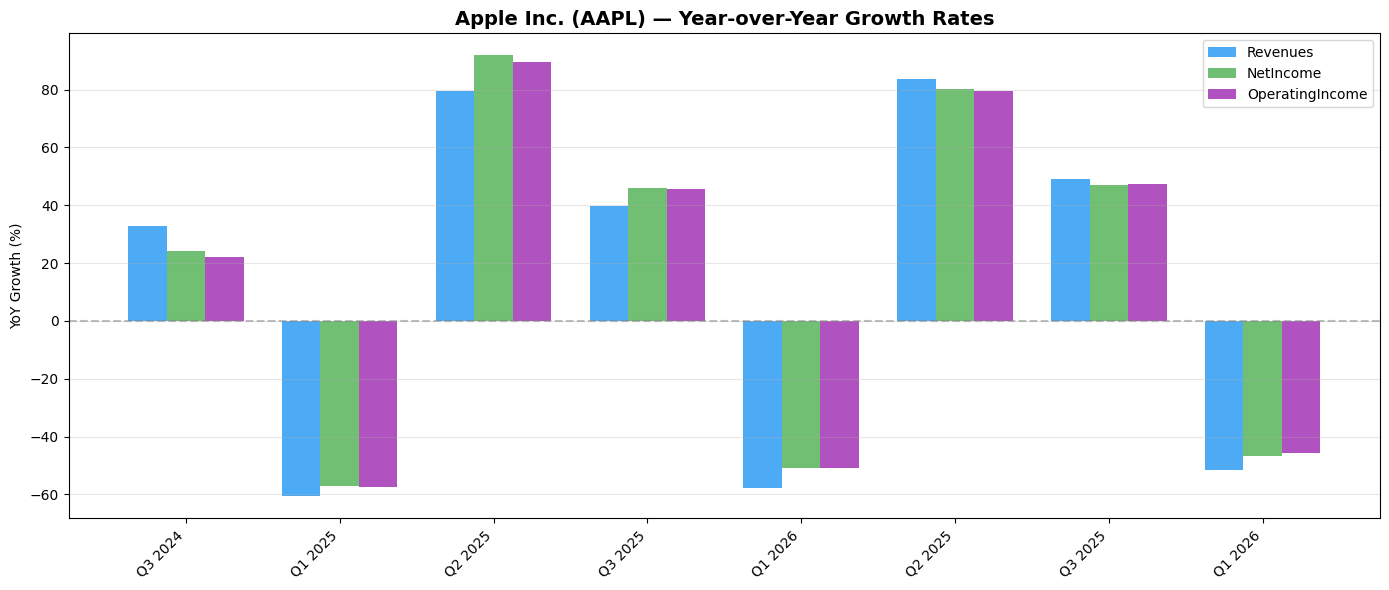

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {"Revenues": "#2196F3", "NetIncome": "#4CAF50", "OperatingIncome": "#9C27B0"}
bar_width = 0.25
x_positions = None

for idx, (metric_name, color) in enumerate(colors.items()):
    if metric_name not in financial_data:
        continue

    entries = financial_data[metric_name][-NUM_QUARTERS:]
    growth = compute_growth(entries)
    # Filter to entries with YoY data
    yoy_data = [g for g in growth if g["yoy_growth"] is not None][-8:]

    if not yoy_data:
        continue

    labels = [f"{g['fiscal_period']} {g['fiscal_year']}" for g in yoy_data]
    yoy_vals = [g["yoy_growth"] for g in yoy_data]

    if x_positions is None:
        import numpy as np
        x_positions = np.arange(len(labels))

    offset = (idx - 1) * bar_width
    bars = ax.bar(x_positions[:len(yoy_vals)] + offset, yoy_vals, bar_width,
                  label=metric_name, color=color, alpha=0.8)

if x_positions is not None:
    ax.set_xticks(x_positions[:len(labels)])
    ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_title(f"{COMPANY_NAME} ({TICKER}) — Year-over-Year Growth Rates", fontsize=14, fontweight="bold")
ax.set_ylabel("YoY Growth (%)")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 9. Filing Links & Raw Data Access

Direct links to the original 10-Q filings on SEC EDGAR for further reading.

In [ ]:
print(f"🔗 SEC EDGAR Links for {COMPANY_NAME}\n")
print(f"  Company Page:  https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany&CIK={CIK}&type=10-Q")
print(f"  Company Facts: https://data.sec.gov/api/xbrl/companyfacts/CIK{CIK}.json")
print(f"  Submissions:   https://data.sec.gov/submissions/CIK{CIK}.json")
print()

print("📄 Recent 10-Q Filing Links:\n")
for f in filings[:5]:
    doc_url = f"https://www.sec.gov/Archives/edgar/data/{int(CIK)}/{f['accession_clean']}/{f['primary_doc']}"
    print(f"  {f['filing_date']}:")
    print(f"    {doc_url}\n")

# Export data to CSV
if not df.empty:
    csv_filename = f"/content/{TICKER}_10Q_financial_data.csv"
    df.to_csv(csv_filename, index=False)
    print(f"\n💾 Data exported to: {csv_filename}")
    print("   (Download from Colab's file browser on the left panel)")

🔗 SEC EDGAR Links for Apple Inc.

  Company Page:  https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany&CIK=0000320193&type=10-Q
  Company Facts: https://data.sec.gov/api/xbrl/companyfacts/CIK0000320193.json
  Submissions:   https://data.sec.gov/submissions/CIK0000320193.json

📄 Recent 10-Q Filing Links:

  2026-01-30:
    https://www.sec.gov/Archives/edgar/data/320193/000032019326000006/aapl-20251227.htm

  2025-08-01:
    https://www.sec.gov/Archives/edgar/data/320193/000032019325000073/aapl-20250628.htm

  2025-05-02:
    https://www.sec.gov/Archives/edgar/data/320193/000032019325000057/aapl-20250329.htm

  2025-01-31:
    https://www.sec.gov/Archives/edgar/data/320193/000032019325000008/aapl-20241228.htm

  2024-08-02:
    https://www.sec.gov/Archives/edgar/data/320193/000032019324000081/aapl-20240629.htm


💾 Data exported to: /content/AAPL_10Q_financial_data.csv
   (Download from Colab's file browser on the left panel)


---

## 10. Ollama AI Gateway — Setup

Install and configure Ollama with a local LLM for AI-powered financial analysis. This runs entirely on the Colab GPU — no API keys needed.

> **Architecture:** The gateway is designed as a modular service so multiple analysis tasks can call it in parallel (next feature).

In [ ]:
%%bash
# Install zstd (required by Ollama installer) then install Ollama
apt-get update -qq && apt-get install -y -qq zstd > /dev/null 2>&1
curl -fsSL https://ollama.com/install.sh | sh
echo "✅ Ollama installed"
ollama --version

✅ Ollama installed


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
import subprocess, os, signal

# Start Ollama server in the background
env = os.environ.copy()
env["OLLAMA_HOST"] = "0.0.0.0:11434"

ollama_proc = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    env=env
)

# Wait for server to be ready
import time
OLLAMA_BASE = "http://localhost:11434"

for i in range(30):
    try:
        r = requests.get(f"{OLLAMA_BASE}/api/tags", timeout=2)
        if r.status_code == 200:
            print(f"✅ Ollama server running on {OLLAMA_BASE} (PID: {ollama_proc.pid})")
            break
    except:
        pass
    time.sleep(1)
else:
    print("❌ Ollama server failed to start. Check GPU availability.")
    print(ollama_proc.stderr.read().decode())

✅ Ollama server running on http://localhost:11434 (PID: 11553)


### Pull the AI Model

Pulling **Qwen2.5:3B** — a strong 3B parameter model that fits comfortably in Colab's GPU memory while delivering solid reasoning for financial analysis. Fast inference, good at structured data interpretation.

> **Alternatives:** Change `MODEL_NAME` to `"gemma2:2b"` (lighter) or `"phi3:3.8b"` / `"llama3.1:8b"` (heavier, better reasoning).

In [ ]:
# ---- MODEL SELECTION ----
MODEL_NAME = "qwen2.5:3b"  # Change to "gemma2:2b", "phi3:3.8b", or "llama3.1:8b"

print(f"⬇️  Pulling {MODEL_NAME} — this may take a few minutes on first run...\n")

pull_resp = requests.post(
    f"{OLLAMA_BASE}/api/pull",
    json={"name": MODEL_NAME, "stream": False},
    timeout=600
)

if pull_resp.status_code == 200:
    print(f"✅ Model '{MODEL_NAME}' ready!")
else:
    print(f"❌ Pull failed: {pull_resp.text}")

# Verify model is loaded
tags = requests.get(f"{OLLAMA_BASE}/api/tags").json()
models = [m["name"] for m in tags.get("models", [])]
print(f"\n📦 Available models: {models}")

⬇️  Pulling qwen2.5:3b — this may take a few minutes on first run...

✅ Model 'qwen2.5:3b' ready!

📦 Available models: ['qwen2.5:3b']


## 11. Ollama AI Gateway — Client

A reusable gateway class that wraps the Ollama API. Designed for **parallel execution** — each call is stateless and thread-safe, so multiple analysis tasks can hit the gateway concurrently.

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from typing import Optional
import threading

@dataclass
class OllamaGateway:
    """
    Stateless AI gateway wrapping the Ollama REST API.
    Thread-safe — designed for parallel analysis tasks.
    """
    base_url: str = "http://localhost:11434"
    model: str = "qwen2.5:3b"
    temperature: float = 0.3
    max_tokens: int = 1024
    timeout: int = 600
    _lock: threading.Lock = field(default_factory=threading.Lock, repr=False)

    def generate(self, prompt: str, system: str = "", temperature: float = None,
                 max_tokens: int = None) -> dict:
        """Send a single prompt to the model. Returns dict with 'response' and metadata."""
        payload = {
            "model": self.model,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": temperature or self.temperature,
                "num_predict": max_tokens or self.max_tokens,
            }
        }
        if system:
            payload["system"] = system

        resp = requests.post(f"{self.base_url}/api/generate", json=payload, timeout=self.timeout)
        resp.raise_for_status()
        data = resp.json()
        return {
            "response": data.get("response", ""),
            "model": data.get("model", ""),
            "eval_count": data.get("eval_count", 0),
            "eval_duration_ms": data.get("eval_duration", 0) / 1e6,
            "total_duration_ms": data.get("total_duration", 0) / 1e6,
        }

    def analyze_batch(self, tasks: list[dict], max_workers: int = 2) -> list[dict]:
        """
        Run multiple analysis tasks in parallel.
        Each task is a dict with 'name', 'prompt', and optional 'system'.
        Returns list of results in same order.

        Ready for next feature: parallel multi-company / multi-metric analysis.
        """
        results = [None] * len(tasks)

        def _run(idx, task):
            result = self.generate(
                prompt=task["prompt"],
                system=task.get("system", ""),
                max_tokens=task.get("max_tokens", None),
            )
            result["task_name"] = task["name"]
            return idx, result

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {executor.submit(_run, i, t): i for i, t in enumerate(tasks)}
            for future in as_completed(futures):
                idx, result = future.result()
                results[idx] = result

        return results

    def health(self) -> bool:
        """Check if the Ollama server is reachable."""
        try:
            r = requests.get(f"{self.base_url}/api/tags", timeout=5)
            return r.status_code == 200
        except:
            return False


# Initialize the gateway
gateway = OllamaGateway(model=MODEL_NAME, timeout=600)

# Verify
if gateway.health():
    print(f"✅ OllamaGateway initialized — model: {gateway.model}")
    print(f"   Parallel batch support: up to 2 concurrent tasks")
    print(f"   Timeout: {gateway.timeout}s | Max tokens: {gateway.max_tokens}")
    print(f"   Base URL: {gateway.base_url}")
else:
    print("❌ Gateway health check failed — is Ollama running?")

✅ OllamaGateway initialized — model: qwen2.5:3b
   Parallel batch support: up to 2 concurrent tasks
   Timeout: 600s | Max tokens: 1024
   Base URL: http://localhost:11434


## 12. AI Financial Analysis

Run the local LLM against the extracted 10-Q data to generate insights — revenue trends, profitability assessment, risk flags, and outlook.

In [ ]:
def build_financial_summary() -> str:
    """Build a text summary of financial data for the LLM prompt."""
    lines = [f"Company: {COMPANY_NAME} (Ticker: {TICKER})\n"]

    # Latest quarter snapshot
    lines.append("=== MOST RECENT QUARTER ===")
    for metric, entries in financial_data.items():
        if entries:
            e = entries[-1]
            val = e["value"]
            if abs(val) >= 1e9:
                val_str = f"${val/1e9:.2f}B"
            elif abs(val) >= 1e6:
                val_str = f"${val/1e6:.1f}M"
            else:
                val_str = f"${val:.2f}"
            lines.append(f"  {metric}: {val_str} (period ending {e['period']})")

    # Growth data for key metrics
    lines.append("\n=== QUARTERLY GROWTH (Last 6 Quarters) ===")
    for metric_name in ["Revenues", "NetIncome", "OperatingIncome"]:
        if metric_name not in financial_data:
            continue
        entries = financial_data[metric_name][-8:]
        growth = compute_growth(entries)
        lines.append(f"\n  {metric_name}:")
        for g in growth[-6:]:
            val_str = f"${g['value']/1e9:.2f}B" if abs(g["value"]) >= 1e9 else f"${g['value']/1e6:.0f}M"
            yoy_str = f"YoY: {g['yoy_growth']:+.1f}%" if g["yoy_growth"] is not None else ""
            lines.append(f"    {g['fiscal_period']} FY{g['fiscal_year']}: {val_str}  {yoy_str}")

    # Ratios
    if ratios:
        lines.append("\n=== KEY RATIOS ===")
        for name, val in ratios.items():
            if "Equity" in name and isinstance(val, float) and abs(val) > 10:
                lines.append(f"  {name}: {val:.2f}x")
            else:
                lines.append(f"  {name}: {val:.1f}%")

    return "\n".join(lines)


FINANCIAL_CONTEXT = build_financial_summary()
print("📄 Financial context prepared for AI analysis:\n")
print(FINANCIAL_CONTEXT)

📄 Financial context prepared for AI analysis:

Company: Apple Inc. (Ticker: AAPL)

=== MOST RECENT QUARTER ===
  Revenues: $143.76B (period ending 2025-12-27)
  NetIncome: $42.10B (period ending 2025-12-27)
  TotalAssets: $379.30B (period ending 2025-12-27)
  TotalLiabilities: $291.11B (period ending 2025-12-27)
  StockholdersEquity: $88.19B (period ending 2025-12-27)
  CashAndEquivalents: $45.32B (period ending 2025-12-27)
  OperatingIncome: $50.85B (period ending 2025-12-27)
  EarningsPerShare: $2.85 (period ending 2025-12-27)
  GrossProfit: $69.23B (period ending 2025-12-27)

=== QUARTERLY GROWTH (Last 6 Quarters) ===

  Revenues:
    Q2 FY2025: $210.33B  
    Q3 FY2025: $296.11B  
    Q1 FY2026: $124.30B  YoY: -57.7%
    Q2 FY2025: $219.66B  YoY: +83.7%
    Q3 FY2025: $313.69B  YoY: +49.1%
    Q1 FY2026: $143.76B  YoY: -51.5%

  NetIncome:
    Q2 FY2025: $57.55B  
    Q3 FY2025: $79.00B  
    Q1 FY2026: $36.33B  YoY: -50.9%
    Q2 FY2025: $61.11B  YoY: +80.2%
    Q3 FY2025: $84.54B

In [ ]:
SYSTEM_PROMPT = "You are a senior financial analyst. Analyze SEC 10-Q data. Be concise and cite numbers."

ANALYSIS_PROMPT = f"""Analyze this 10-Q data for {COMPANY_NAME} ({TICKER}):

{FINANCIAL_CONTEXT}

Cover in ~300 words:
1. Revenue trend — growing or slowing?
2. Profitability — margin quality?
3. Balance sheet — leverage and cash?
4. Key risks?
5. Near-term outlook?"""

print(f"🤖 Sending to {MODEL_NAME} for analysis (this may take a few minutes on CPU)...\n")
result = gateway.generate(prompt=ANALYSIS_PROMPT, system=SYSTEM_PROMPT, max_tokens=512)

print(f"{'='*70}")
print(f"  AI ANALYSIS — {COMPANY_NAME} ({TICKER})")
print(f"  Model: {result['model']} | Tokens: {result['eval_count']} | Time: {result['total_duration_ms']:.0f}ms")
print(f"{'='*70}\n")
print(result["response"])

🤖 Sending to qwen2.5:3b for analysis (this may take a few minutes on CPU)...

  AI ANALYSIS — Apple Inc. (AAPL)
  Model: qwen2.5:3b | Tokens: 301 | Time: 296887ms

In the most recent quarter, Apple Inc.'s revenue of $143.76 billion represents a significant growth from its previous quarter's $124.30 billion (YoY - 51.5%), indicating that while revenues have slowed down, they are still growing. The company’s net income at $42.10 billion shows substantial profitability, with a Net Profit Margin of 29.3%, suggesting margin quality is strong.

On the balance sheet front, Apple's total assets amount to $379.30 billion and liabilities reach $291.11 billion, resulting in equity of $88.19 billion. The company holds substantial cash reserves at $45.32 billion, indicating a robust liquidity position despite leverage levels (Debt-to-Asset: 76.7%, Debt-to-Equity: 3.3%). Although the debt ratio is high, it remains manageable given the equity cushion.

In terms of key risks, Apple faces challenges su

## 13. Parallel Analysis Demo (Gateway Batch Mode)

Demonstrates the gateway's `analyze_batch()` — running multiple independent analysis prompts concurrently. This is the foundation for the **next feature**: parallel multi-company or multi-metric deep dives.

In [ ]:
# Define parallel analysis tasks — each runs independently against the LLM
parallel_tasks = [
    {
        "name": "risk_assessment",
        "system": "You are a risk analyst. Be direct and concise.",
        "prompt": f"Top 3 financial risks for {COMPANY_NAME} based on: Revenue ${revenue/1e9:.0f}B, Net Income ${net_income/1e9:.0f}B, Debt-to-Equity {ratios.get('Debt-to-Equity', 0):.1f}x, Cash ${cash/1e9:.0f}B. Rate each Low/Medium/High. 100 words max.",
        "max_tokens": 256,
    },
    {
        "name": "margin_quality",
        "system": "You are an equity research analyst.",
        "prompt": f"Assess margin quality for {COMPANY_NAME}: Gross Margin {ratios.get('Gross Profit Margin', 0):.1f}%, Operating Margin {ratios.get('Operating Margin', 0):.1f}%, Net Margin {ratios.get('Net Profit Margin', 0):.1f}%. How sustainable? 100 words max.",
        "max_tokens": 256,
    },
    {
        "name": "balance_sheet",
        "system": "You are a credit analyst.",
        "prompt": f"Evaluate balance sheet health for {COMPANY_NAME}: Assets ${total_assets/1e9:.0f}B, Liabilities ${total_liabilities/1e9:.0f}B, Equity ${equity/1e9:.0f}B, Cash ${cash/1e9:.0f}B. Debt-to-Asset {ratios.get('Debt-to-Asset', 0):.1f}%. Is this healthy? 100 words max.",
        "max_tokens": 256,
    },
]

print(f"🚀 Running {len(parallel_tasks)} analysis tasks in parallel...\n")

start_time = time.time()
batch_results = gateway.analyze_batch(parallel_tasks, max_workers=2)
elapsed = time.time() - start_time

for r in batch_results:
    print(f"{'─'*70}")
    print(f"  📋 {r['task_name'].upper().replace('_', ' ')}")
    print(f"     Tokens: {r['eval_count']} | Time: {r['total_duration_ms']:.0f}ms")
    print(f"{'─'*70}")
    print(r["response"])
    print()

print(f"{'='*70}")
print(f"✅ All {len(parallel_tasks)} tasks completed in {elapsed:.1f}s total")
print(f"   (Sequential estimate: ~{sum(r['total_duration_ms'] for r in batch_results)/1000:.1f}s)")

🚀 Running 3 analysis tasks in parallel...

──────────────────────────────────────────────────────────────────────
  📋 RISK ASSESSMENT
     Tokens: 61 | Time: 33581ms
──────────────────────────────────────────────────────────────────────
High: High debt-to-equity ratio (3.3x) exposes Apple to higher financial leverage risks.
Medium: Revenue of $144B is stable but subject to market fluctuations and competition.
Low: Net Income of $42B suggests robust profitability, mitigating immediate financial risk.

──────────────────────────────────────────────────────────────────────
  📋 MARGIN QUALITY
     Tokens: 63 | Time: 64041ms
──────────────────────────────────────────────────────────────────────
Apple's margin profile is strong, with gross, operating, and net margins of 48.2%, 35.4%, and 29.3% respectively. However, sustainability depends on continued robust sales growth, efficient cost management, and competitive pricing power in a highly competitive tech sector.

──────────────────────────

---

## 14. AI-to-Chart Algorithm

Converts LLM analysis into structured visual charts using a **two-pass pipeline**:

1. **Scoring Pass** — Prompt the LLM to return structured JSON with numeric scores (0-10) across financial dimensions
2. **Parse & Validate** — Extract JSON from response, validate schema, handle malformed output
3. **Render** — Generate radar chart, scorecard bar chart, risk heatmap, and trend arrows from the scores

> This decouples the "thinking" (LLM) from the "rendering" (matplotlib), making it model-agnostic and deterministic on the viz side.

In [ ]:
import re, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# ─────────────────────────────────────────────────────────────────────
# STEP 1: Structured JSON Prompts — force the LLM to return chart-ready data
# ─────────────────────────────────────────────────────────────────────

SCORECARD_PROMPT = f"""Analyze {COMPANY_NAME} ({TICKER}) financials and return ONLY valid JSON — no other text.

Data:
- Revenue: ${revenue/1e9:.1f}B | Net Income: ${net_income/1e9:.1f}B
- Gross Margin: {ratios.get('Gross Profit Margin',0):.1f}% | Operating Margin: {ratios.get('Operating Margin',0):.1f}% | Net Margin: {ratios.get('Net Profit Margin',0):.1f}%
- Total Assets: ${total_assets/1e9:.1f}B | Liabilities: ${total_liabilities/1e9:.1f}B | Equity: ${equity/1e9:.1f}B
- Cash: ${cash/1e9:.1f}B | Debt-to-Equity: {ratios.get('Debt-to-Equity',0):.2f}x
- ROA: {ratios.get('ROA (Annualized)',0):.1f}% | ROE: {ratios.get('ROE (Annualized)',0):.1f}%

Return this exact JSON structure with scores 0-10 (10=best) and a one-line reason for each:
{{
  "company": "{TICKER}",
  "scores": {{
    "revenue_growth": {{"score": <0-10>, "label": "<one line>"}},
    "profitability": {{"score": <0-10>, "label": "<one line>"}},
    "margin_quality": {{"score": <0-10>, "label": "<one line>"}},
    "cash_position": {{"score": <0-10>, "label": "<one line>"}},
    "leverage_risk": {{"score": <0-10>, "label": "<one line>"}},
    "earnings_quality": {{"score": <0-10>, "label": "<one line>"}},
    "capital_efficiency": {{"score": <0-10>, "label": "<one line>"}},
    "overall_health": {{"score": <0-10>, "label": "<one line>"}}
  }},
  "risks": [
    {{"name": "<risk>", "severity": <1-5>, "category": "<market|operational|financial|regulatory>"}},
    {{"name": "<risk>", "severity": <1-5>, "category": "<market|operational|financial|regulatory>"}},
    {{"name": "<risk>", "severity": <1-5>, "category": "<market|operational|financial|regulatory>"}}
  ],
  "outlook": "<bullish|neutral|bearish>",
  "outlook_reason": "<one sentence>"
}}

CRITICAL: Return ONLY the JSON object. No markdown, no explanation, no code fences."""

print("✅ Structured scoring prompt ready")
print(f"   Dimensions: 8 scores + 3 risks + outlook")
print(f"   Target: {COMPANY_NAME} ({TICKER})")

✅ Structured scoring prompt ready
   Dimensions: 8 scores + 3 risks + outlook
   Target: Apple Inc. (AAPL)


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# STEP 2: Parse & Validate — extract JSON from LLM response robustly
# ─────────────────────────────────────────────────────────────────────

def extract_json(text: str) -> dict:
    """
    Robust JSON extractor — handles common LLM output quirks:
    1. Clean JSON response
    2. JSON wrapped in markdown code fences
    3. JSON embedded in surrounding text
    4. Trailing commas, single quotes, etc.
    """
    # Strip markdown code fences if present
    text = re.sub(r'```(?:json)?\s*', '', text).strip()
    text = re.sub(r'```\s*$', '', text).strip()

    # Try direct parse first
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Try to find JSON object in the text
    brace_depth = 0
    start = None
    for i, ch in enumerate(text):
        if ch == '{':
            if brace_depth == 0:
                start = i
            brace_depth += 1
        elif ch == '}':
            brace_depth -= 1
            if brace_depth == 0 and start is not None:
                candidate = text[start:i+1]
                try:
                    return json.loads(candidate)
                except json.JSONDecodeError:
                    # Try fixing trailing commas
                    fixed = re.sub(r',\s*([}\]])', r'\1', candidate)
                    try:
                        return json.loads(fixed)
                    except json.JSONDecodeError:
                        continue

    raise ValueError(f"Could not extract valid JSON from LLM response:\n{text[:200]}...")


def validate_scorecard(data: dict) -> dict:
    """Validate and normalize the scorecard JSON schema."""
    REQUIRED_SCORES = [
        "revenue_growth", "profitability", "margin_quality", "cash_position",
        "leverage_risk", "earnings_quality", "capital_efficiency", "overall_health"
    ]

    scores = data.get("scores", {})
    validated = {"company": data.get("company", TICKER), "scores": {}, "risks": [], "outlook": "neutral", "outlook_reason": ""}

    for key in REQUIRED_SCORES:
        if key in scores and isinstance(scores[key], dict):
            s = max(0, min(10, float(scores[key].get("score", 5))))
            validated["scores"][key] = {
                "score": s,
                "label": str(scores[key].get("label", ""))[:80]
            }
        else:
            validated["scores"][key] = {"score": 5.0, "label": "No data"}

    for risk in data.get("risks", [])[:5]:
        if isinstance(risk, dict):
            validated["risks"].append({
                "name": str(risk.get("name", "Unknown"))[:40],
                "severity": max(1, min(5, int(risk.get("severity", 3)))),
                "category": str(risk.get("category", "other"))[:20]
            })

    validated["outlook"] = data.get("outlook", "neutral")
    validated["outlook_reason"] = str(data.get("outlook_reason", ""))[:120]

    return validated


print("✅ JSON parser & validator ready")
print("   Handles: code fences, embedded JSON, trailing commas, schema enforcement")

✅ JSON parser & validator ready
   Handles: code fences, embedded JSON, trailing commas, schema enforcement


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# STEP 3: Send to LLM and parse the structured response
# ─────────────────────────────────────────────────────────────────────

print(f"🤖 Requesting structured JSON analysis from {MODEL_NAME}...\n")

raw_result = gateway.generate(
    prompt=SCORECARD_PROMPT,
    system="You are a financial analyst API. Return ONLY valid JSON. No markdown. No explanation.",
    max_tokens=768,
    temperature=0.1,  # Low temp for structured output
)

print(f"   Model responded in {raw_result['total_duration_ms']/1000:.1f}s ({raw_result['eval_count']} tokens)\n")

# Parse and validate
try:
    parsed = extract_json(raw_result["response"])
    scorecard = validate_scorecard(parsed)
    print("✅ JSON parsed and validated successfully!\n")

    # Display the scorecard data
    print(f"Company: {scorecard['company']}")
    print(f"Outlook: {scorecard['outlook'].upper()} — {scorecard['outlook_reason']}\n")

    print("Scores:")
    for key, val in scorecard["scores"].items():
        bar = "█" * int(val["score"]) + "░" * (10 - int(val["score"]))
        print(f"  {key:<22} [{bar}] {val['score']:.0f}/10  {val['label']}")

    print(f"\nRisks ({len(scorecard['risks'])}):")
    for r in scorecard["risks"]:
        severity_icon = "🔴" if r["severity"] >= 4 else "🟡" if r["severity"] >= 2 else "🟢"
        print(f"  {severity_icon} [{r['severity']}/5] {r['name']} ({r['category']})")

except ValueError as e:
    print(f"❌ Parse failed: {e}")
    print(f"\nRaw response:\n{raw_result['response'][:500]}")

🤖 Requesting structured JSON analysis from qwen2.5:3b...

   Model responded in 246.2s (363 tokens)

✅ JSON parsed and validated successfully!

Company: AAPL
Outlook: NEUTRAL — AAPL's financials are solid with no immediate risks but also no clear signs of significant upside potential.

Scores:
  revenue_growth         [████████░░] 8/10  Revenue growth is strong with $143.8B in revenue.
  profitability          [█████████░] 9/10  High profitability margins indicate strong financial performance.
  margin_quality         [███████░░░] 7/10  Gross and operating margins are healthy but net margin could be improved.
  cash_position          [██████████] 10/10  Strong cash position of $45.3B provides significant liquidity.
  leverage_risk          [██████░░░░] 6/10  High debt-to-equity ratio (3.30x) suggests leverage risk.
  earnings_quality       [████████░░] 8/10  ROA and ROE scores indicate high earnings quality.
  capital_efficiency     [█████░░░░░] 5/10  Capital efficiency could be improv

### Render: Radar Chart + Scorecard + Risk Heatmap

The algorithm converts the validated JSON into a **4-panel dashboard**:
- **Radar Chart** — Overall financial profile at a glance
- **Score Bars** — Individual dimension scores with color coding
- **Risk Matrix** — Severity vs category heatmap
- **Outlook Gauge** — Bullish/Neutral/Bearish indicator

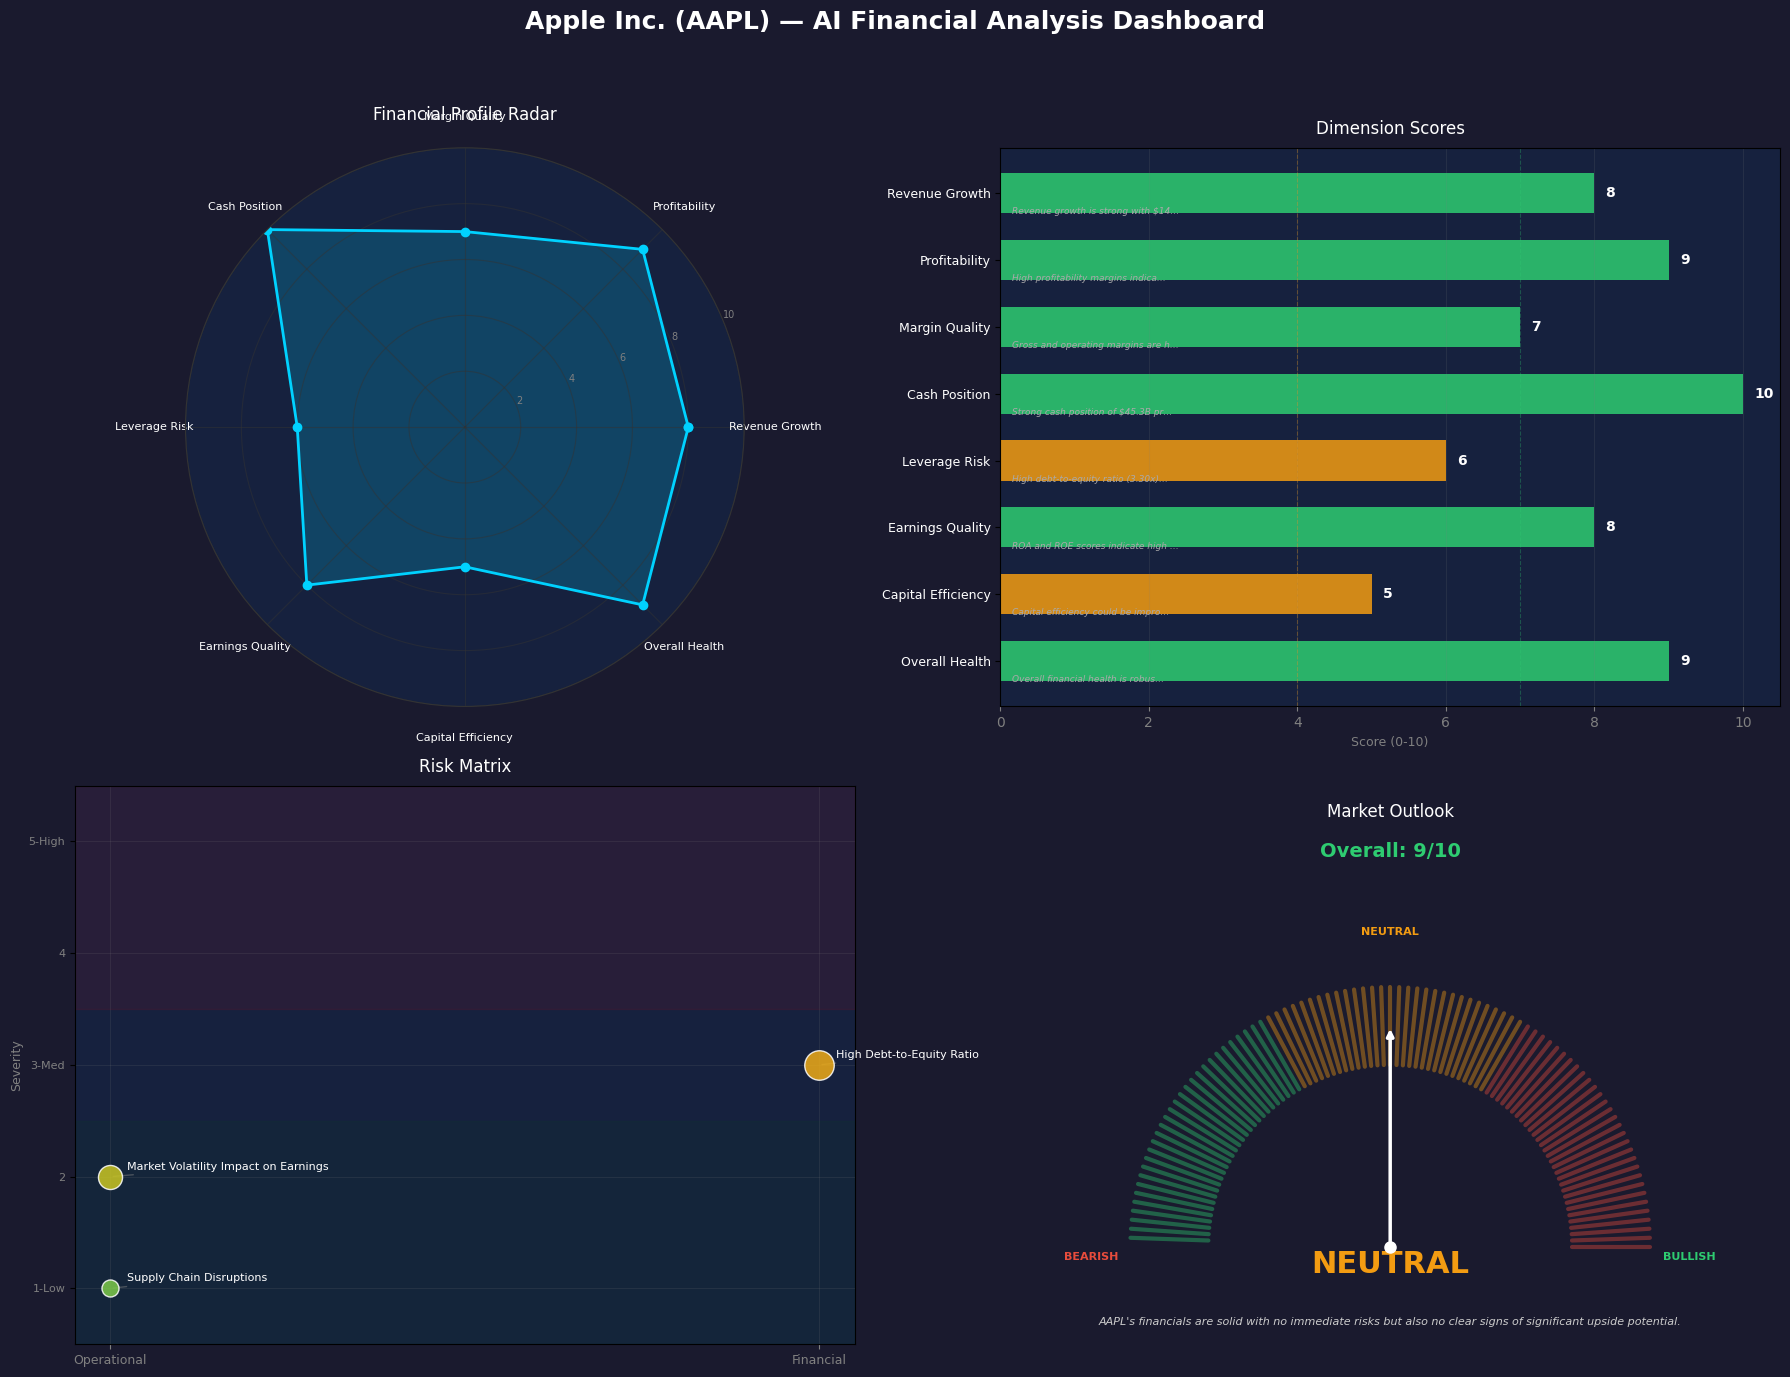


💾 Dashboard saved to /content/AAPL_ai_dashboard.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# STEP 4: RENDER — Convert scorecard JSON into a visual dashboard
# ─────────────────────────────────────────────────────────────────────

def score_color(score):
    """Map score 0-10 to a red-yellow-green color."""
    if score >= 7:
        return "#2ecc71"  # green
    elif score >= 4:
        return "#f39c12"  # amber
    else:
        return "#e74c3c"  # red

def render_dashboard(sc: dict, company_name: str, ticker: str):
    """Render a 4-panel financial analysis dashboard from scorecard JSON."""

    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor("#1a1a2e")
    fig.suptitle(f"{company_name} ({ticker}) — AI Financial Analysis Dashboard",
                 fontsize=18, fontweight="bold", color="white", y=0.98)

    scores = sc["scores"]
    labels = list(scores.keys())
    values = [scores[k]["score"] for k in labels]
    display_labels = [k.replace("_", " ").title() for k in labels]

    # ── PANEL 1: Radar Chart ──────────────────────────────────────
    ax1 = fig.add_subplot(221, polar=True)
    ax1.set_facecolor("#16213e")

    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values_plot = values + [values[0]]  # close the polygon
    angles += angles[:1]

    ax1.plot(angles, values_plot, "o-", linewidth=2, color="#00d2ff", markersize=6)
    ax1.fill(angles, values_plot, alpha=0.2, color="#00d2ff")

    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(display_labels, fontsize=8, color="white")
    ax1.set_ylim(0, 10)
    ax1.set_yticks([2, 4, 6, 8, 10])
    ax1.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=7, color="gray")
    ax1.tick_params(axis='x', pad=12)
    ax1.spines['polar'].set_color('#333')
    ax1.grid(color="#333", alpha=0.5)
    ax1.set_title("Financial Profile Radar", fontsize=12, color="white", pad=20)

    # ── PANEL 2: Score Bars ───────────────────────────────────────
    ax2 = fig.add_subplot(222)
    ax2.set_facecolor("#16213e")

    y_pos = np.arange(N)
    colors = [score_color(v) for v in values]

    bars = ax2.barh(y_pos, values, color=colors, height=0.6, alpha=0.85, edgecolor="none")
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(display_labels, fontsize=9, color="white")
    ax2.set_xlim(0, 10.5)
    ax2.set_xlabel("Score (0-10)", color="gray", fontsize=9)
    ax2.invert_yaxis()

    # Add score text + label on bars
    for i, (v, key) in enumerate(zip(values, labels)):
        ax2.text(v + 0.15, i, f"{v:.0f}", va="center", fontsize=10, fontweight="bold", color="white")
        label_text = scores[key]["label"]
        if len(label_text) > 35:
            label_text = label_text[:33] + "…"
        ax2.text(0.15, i + 0.28, label_text, va="center", fontsize=6.5, color="#aaa", style="italic")

    # Reference lines
    ax2.axvline(x=7, color="#2ecc71", linestyle="--", alpha=0.3, linewidth=0.8)
    ax2.axvline(x=4, color="#f39c12", linestyle="--", alpha=0.3, linewidth=0.8)
    ax2.grid(axis="x", alpha=0.15, color="gray")
    ax2.tick_params(axis="x", colors="gray")
    ax2.set_title("Dimension Scores", fontsize=12, color="white", pad=10)

    # ── PANEL 3: Risk Matrix ──────────────────────────────────────
    ax3 = fig.add_subplot(223)
    ax3.set_facecolor("#16213e")

    risks = sc["risks"]
    if risks:
        categories = list(set(r["category"] for r in risks))
        cat_map = {c: i for i, c in enumerate(categories)}

        risk_cmap = LinearSegmentedColormap.from_list("risk", ["#2ecc71", "#f1c40f", "#e74c3c"])

        for r in risks:
            x = cat_map[r["category"]]
            y = r["severity"]
            size = r["severity"] * 150
            color = risk_cmap(r["severity"] / 5.0)
            ax3.scatter(x, y, s=size, c=[color], alpha=0.85, edgecolors="white", linewidth=1, zorder=5)
            ax3.annotate(r["name"], (x, y), textcoords="offset points",
                        xytext=(12, 5), fontsize=8, color="white",
                        arrowprops=dict(arrowstyle="-", color="gray", alpha=0.5))

        ax3.set_xticks(range(len(categories)))
        ax3.set_xticklabels([c.title() for c in categories], fontsize=9, color="white")
        ax3.set_ylim(0.5, 5.5)
        ax3.set_yticks([1, 2, 3, 4, 5])
        ax3.set_yticklabels(["1-Low", "2", "3-Med", "4", "5-High"], fontsize=8, color="gray")
        ax3.set_ylabel("Severity", color="gray", fontsize=9)
        ax3.grid(alpha=0.15, color="gray")

        # Danger zone shading
        ax3.axhspan(3.5, 5.5, alpha=0.08, color="red")
        ax3.axhspan(0.5, 2.5, alpha=0.05, color="green")

    ax3.set_title("Risk Matrix", fontsize=12, color="white", pad=10)
    ax3.tick_params(axis="x", colors="gray")

    # ── PANEL 4: Outlook Gauge + Summary ──────────────────────────
    ax4 = fig.add_subplot(224)
    ax4.set_facecolor("#16213e")
    ax4.set_xlim(-1.5, 1.5)
    ax4.set_ylim(-0.2, 1.6)
    ax4.set_aspect("equal")
    ax4.axis("off")

    # Gauge arc
    outlook = sc["outlook"].lower()
    outlook_colors = {"bullish": "#2ecc71", "neutral": "#f39c12", "bearish": "#e74c3c"}
    outlook_angles = {"bullish": 135, "neutral": 90, "bearish": 45}
    gauge_color = outlook_colors.get(outlook, "#f39c12")
    needle_angle = outlook_angles.get(outlook, 90)

    # Draw gauge background arc
    for i in range(0, 180, 2):
        angle_rad = np.radians(i)
        seg_color = "#e74c3c" if i < 60 else "#f39c12" if i < 120 else "#2ecc71"
        x1 = np.cos(angle_rad)
        y1 = np.sin(angle_rad)
        x2 = np.cos(angle_rad) * 0.7
        y2 = np.sin(angle_rad) * 0.7
        ax4.plot([x1, x2], [y1, y2], color=seg_color, linewidth=3, alpha=0.4, solid_capstyle="round")

    # Needle
    needle_rad = np.radians(needle_angle)
    ax4.annotate("", xy=(np.cos(needle_rad) * 0.85, np.sin(needle_rad) * 0.85), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="white", lw=2.5))
    ax4.plot(0, 0, "o", color="white", markersize=8, zorder=10)

    # Labels
    ax4.text(-1.15, -0.05, "BEARISH", fontsize=8, color="#e74c3c", ha="center", fontweight="bold")
    ax4.text(0, 1.2, "NEUTRAL", fontsize=8, color="#f39c12", ha="center", fontweight="bold")
    ax4.text(1.15, -0.05, "BULLISH", fontsize=8, color="#2ecc71", ha="center", fontweight="bold")

    # Outlook text
    ax4.text(0, -0.1, outlook.upper(), fontsize=22, ha="center", fontweight="bold", color=gauge_color)
    ax4.text(0, -0.3, sc["outlook_reason"], fontsize=8, ha="center", color="#ccc",
             wrap=True, style="italic")

    # Overall score big number
    overall = scores.get("overall_health", {}).get("score", 5)
    ax4.text(0, 1.5, f"Overall: {overall:.0f}/10", fontsize=14, ha="center",
             fontweight="bold", color=score_color(overall))

    ax4.set_title("Market Outlook", fontsize=12, color="white", pad=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"/content/{ticker}_ai_dashboard.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"\n💾 Dashboard saved to /content/{ticker}_ai_dashboard.png")


# ── RENDER ────────────────────────────────────────────────────────
render_dashboard(scorecard, COMPANY_NAME, TICKER)

### Reusable Function: One-Call Analysis-to-Chart

`analyze_and_chart()` wraps the full pipeline into a single function call — pass any company's financial data and get a dashboard back.

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# FULL PIPELINE: analyze_and_chart() — one-call entry point
# ─────────────────────────────────────────────────────────────────────

def analyze_and_chart(company_name: str, ticker: str, financials: dict,
                      ratios_data: dict, gw: OllamaGateway) -> dict:
    """
    Full AI-to-Chart pipeline:
      1. Build structured prompt from financial data
      2. Send to LLM for JSON scoring
      3. Parse & validate response
      4. Render 4-panel dashboard

    Args:
        company_name: Full company name
        ticker: Stock ticker symbol
        financials: Dict of {metric_name: value} for latest quarter
        ratios_data: Dict of {ratio_name: value}
        gw: OllamaGateway instance

    Returns:
        Dict with scorecard data and render status
    """
    # Build prompt dynamically from whatever financials are passed
    fin_lines = "\n".join(f"- {k}: ${v/1e9:.1f}B" if abs(v) >= 1e6
                          else f"- {k}: {v:.2f}" for k, v in financials.items())
    ratio_lines = "\n".join(f"- {k}: {v:.1f}%" if "Margin" in k or "Asset" in k or "ROA" in k or "ROE" in k
                            else f"- {k}: {v:.2f}x" for k, v in ratios_data.items())

    prompt = f"""Analyze {company_name} ({ticker}) and return ONLY valid JSON.

Financial Data:
{fin_lines}

Ratios:
{ratio_lines}

Return this JSON (scores 0-10, 10=best):
{{"company":"{ticker}","scores":{{"revenue_growth":{{"score":0,"label":""}},"profitability":{{"score":0,"label":""}},"margin_quality":{{"score":0,"label":""}},"cash_position":{{"score":0,"label":""}},"leverage_risk":{{"score":0,"label":""}},"earnings_quality":{{"score":0,"label":""}},"capital_efficiency":{{"score":0,"label":""}},"overall_health":{{"score":0,"label":""}}}},"risks":[{{"name":"","severity":1,"category":"market"}}],"outlook":"neutral","outlook_reason":""}}

Fill in all scores and labels. Return ONLY JSON."""

    # LLM call
    result = gw.generate(
        prompt=prompt,
        system="You are a financial analyst API. Return ONLY valid JSON.",
        max_tokens=768,
        temperature=0.1,
    )

    # Parse
    parsed = extract_json(result["response"])
    sc = validate_scorecard(parsed)

    # Render
    render_dashboard(sc, company_name, ticker)

    return {
        "scorecard": sc,
        "tokens": result["eval_count"],
        "latency_ms": result["total_duration_ms"],
    }


print("✅ analyze_and_chart() ready — full pipeline in one call")
print()
print("Usage:")
print('  result = analyze_and_chart("Apple Inc.", "AAPL", ')
print('      {"Revenue": 143.76e9, "NetIncome": 42.1e9, ...},')
print('      {"Net Profit Margin": 29.3, "Debt-to-Equity": 3.3, ...},')
print("      gateway)")

# Add closing section
print("\n" + "="*60)
print("  AI-to-Chart Algorithm Summary")
print("="*60)
print("  Pipeline: LLM Prompt → JSON → Parse → Validate → Render")
print("  Output:   4-panel dashboard (Radar, Scores, Risks, Outlook)")
print("  Saved:    /content/{ticker}_ai_dashboard.png")
print("  Reuse:    analyze_and_chart(name, ticker, financials, ratios, gw)")

✅ analyze_and_chart() ready — full pipeline in one call

Usage:
  result = analyze_and_chart("Apple Inc.", "AAPL", 
      {"Revenue": 143.76e9, "NetIncome": 42.1e9, ...},
      {"Net Profit Margin": 29.3, "Debt-to-Equity": 3.3, ...},
      gateway)

  AI-to-Chart Algorithm Summary
  Pipeline: LLM Prompt → JSON → Parse → Validate → Render
  Output:   4-panel dashboard (Radar, Scores, Risks, Outlook)
  Saved:    /content/{ticker}_ai_dashboard.png
  Reuse:    analyze_and_chart(name, ticker, financials, ratios, gw)


---

## 15. Parallel Multi-Company Analysis

Fetch SEC EDGAR data for multiple companies simultaneously, run AI scoring in parallel, generate individual + comparison dashboards.

> **Config:** Edit `TICKERS` below. Data fetch is fast (~2s/company). LLM scoring is the bottleneck (~4min/company on CPU).

In [ ]:
import time as _time
from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_company_data(ticker: str) -> dict:
    """Fetch all SEC EDGAR financials for a single ticker. Returns standardized dict."""
    result = {
        "ticker": ticker.upper(), "name": None, "cik": None,
        "financial_data": {}, "latest_financials": {}, "ratios": {},
        "status": "error", "error": None,
    }
    try:
        # 1. Resolve ticker to CIK
        matches = search_company(ticker)
        if not matches:
            raise ValueError(f"No results for '{ticker}'")
        company = next(
            (r for r in matches if r.get("ticker", "").upper() == ticker.upper()),
            matches[0],
        )
        result["name"] = company["name"]
        result["cik"] = company["cik"]

        # 2. Fetch XBRL facts
        _time.sleep(0.15)
        facts = get_company_facts(result["cik"])

        # 3. Extract quarterly data for every metric (reusing existing METRICS + extract_quarterly_data)
        fin_data = {}
        for display_name, metric_candidates in METRICS.items():
            _time.sleep(0.12)
            entries, found_metric = extract_quarterly_data(facts, metric_candidates)
            # Deduplicate by period, keep latest filing
            seen = {}
            for e in entries:
                period = e.get("period", "")
                if period not in seen or e.get("filed", "") > seen[period].get("filed", ""):
                    seen[period] = e
            deduped = sorted(seen.values(), key=lambda x: x.get("period", ""))
            if deduped:
                fin_data[display_name] = deduped
        result["financial_data"] = fin_data

        # 4. Latest value per metric
        latest = {}
        for name, entries in fin_data.items():
            if entries:
                latest[name] = entries[-1].get("value", entries[-1].get("val", 0))
        result["latest_financials"] = latest

        # 5. Compute ratios (same logic as section 7)
        rev = latest.get("Revenues", 0) or 0
        ni  = latest.get("NetIncome", 0) or 0
        gp  = latest.get("GrossProfit", 0) or 0
        oi  = latest.get("OperatingIncome", 0) or 0
        ta  = latest.get("TotalAssets", 0) or 0
        tl  = latest.get("TotalLiabilities", 0) or 0
        eq  = latest.get("StockholdersEquity", 0) or 0
        ca  = latest.get("CashAndEquivalents", 0) or 0

        r = {}
        if rev: r["Gross Profit Margin"] = round(gp / rev * 100, 1)
        if rev: r["Operating Margin"] = round(oi / rev * 100, 1)
        if rev: r["Net Profit Margin"] = round(ni / rev * 100, 1)
        if ta:  r["ROA (Annualized)"] = round((ni * 4) / ta * 100, 1)
        if eq:  r["ROE (Annualized)"] = round((ni * 4) / eq * 100, 1)
        if ta:  r["Debt-to-Asset"] = round(tl / ta * 100, 1)
        if eq:  r["Debt-to-Equity"] = round(tl / eq, 2)
        result["ratios"] = r
        result["status"] = "ok"

    except Exception as exc:
        result["error"] = str(exc)
    return result


def fetch_all_companies(tickers: list, max_workers: int = 4) -> dict:
    """Fetch SEC EDGAR data for all tickers in parallel."""
    results = {}
    total = len(tickers)
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(fetch_company_data, t): t.upper() for t in tickers}
        for i, future in enumerate(as_completed(futures), 1):
            tk = futures[future]
            data = future.result()
            results[tk] = data
            icon = "✅" if data["status"] == "ok" else "❌"
            name = (data.get("name") or tk)[:35]
            print(f"  [{i}/{total}] {icon} {tk:<6} {name}")
            if data["status"] == "error":
                print(f"         Error: {data['error']}")
    return results


# ── Execute: Fetch all companies ──────────────────────────────────
TICKERS = ["AAPL", "MSFT", "GOOG", "AMZN"]

print(f"📡 Fetching SEC EDGAR data for {len(TICKERS)} companies in parallel...\n")
t0 = _time.time()
all_company_data = fetch_all_companies(TICKERS)
elapsed = _time.time() - t0

print(f"\n{'='*75}")
print(f"Fetch complete in {elapsed:.1f}s")
print(f"{'='*75}")
print(f"{'Ticker':<8} {'Company':<32} {'Revenue':>14} {'Net Income':>14} {'Ratios'}")
print("-" * 75)
for tk in TICKERS:
    d = all_company_data.get(tk.upper(), {})
    if d.get("status") == "ok":
        lf = d["latest_financials"]
        rev = lf.get("Revenues", 0) or 0
        ni = lf.get("NetIncome", 0) or 0
        print(f"{tk:<8} {d['name'][:31]:<32} ${rev/1e9:>12.2f}B ${ni/1e9:>12.2f}B  {len(d['ratios'])}")
    else:
        print(f"{tk:<8} {'—':<32} {'—':>14} {'—':>14}  ERROR")

📡 Fetching SEC EDGAR data for 4 companies in parallel...

  [1/4] ✅ GOOG   Alphabet Inc.
  [2/4] ✅ AMZN   AMAZON COM INC
  [3/4] ✅ AAPL   Apple Inc.
  [4/4] ✅ MSFT   MICROSOFT CORP

Fetch complete in 3.0s
Ticker   Company                                 Revenue     Net Income Ratios
---------------------------------------------------------------------------
AAPL     Apple Inc.                       $      143.76B $       42.10B  7
MSFT     MICROSOFT CORP                   $       36.15B $       66.20B  7
GOOG     Alphabet Inc.                    $      289.01B $       97.72B  7
AMZN     AMAZON COM INC                   $      503.54B $       76.48B  7


In [ ]:
def _build_scoring_prompt(ticker: str, data: dict) -> str:
    """Build structured JSON scoring prompt matching validate_scorecard schema."""
    lf = data["latest_financials"]
    r = data["ratios"]
    name = data["name"]

    rev = lf.get("Revenues", 0) or 0
    ni  = lf.get("NetIncome", 0) or 0
    ta  = lf.get("TotalAssets", 0) or 0
    tl  = lf.get("TotalLiabilities", 0) or 0
    eq  = lf.get("StockholdersEquity", 0) or 0
    ca  = lf.get("CashAndEquivalents", 0) or 0

    return f"""You are a financial analyst scoring {name} ({ticker}).

DATA:
Revenue: ${rev/1e9:.1f}B, Net Income: ${ni/1e9:.1f}B, Assets: ${ta/1e9:.1f}B, Liabilities: ${tl/1e9:.1f}B, Equity: ${eq/1e9:.1f}B, Cash: ${ca/1e9:.1f}B
Gross Margin: {r.get('Gross Profit Margin','N/A')}%, Operating Margin: {r.get('Operating Margin','N/A')}%, Net Margin: {r.get('Net Profit Margin','N/A')}%, Debt/Equity: {r.get('Debt-to-Equity','N/A')}x

TASK: Score each dimension from 1 to 10 based on the data above. 10 is excellent, 1 is terrible. You MUST provide real scores, not zeros.

Return ONLY this JSON with your scores filled in:
{{"company":"{ticker}","scores":{{"revenue_growth":{{"score":7,"label":"example"}},"profitability":{{"score":8,"label":"example"}},"margin_quality":{{"score":6,"label":"example"}},"cash_position":{{"score":7,"label":"example"}},"leverage_risk":{{"score":5,"label":"example"}},"earnings_quality":{{"score":7,"label":"example"}},"capital_efficiency":{{"score":6,"label":"example"}},"overall_health":{{"score":7,"label":"example"}}}},"risks":[{{"name":"example risk","severity":3,"category":"financial"}},{{"name":"example risk 2","severity":2,"category":"market"}}],"outlook":"bullish","outlook_reason":"example reason"}}

IMPORTANT: Replace ALL "example" values with your actual analysis. Each score must be between 1-10. Return ONLY JSON."""


def _fallback_scorecard(ticker: str, reason: str = "Parse failed") -> dict:
    dims = ["revenue_growth","profitability","margin_quality","cash_position",
            "leverage_risk","earnings_quality","capital_efficiency","overall_health"]
    return {
        "company": ticker,
        "scores": {d: {"score": 5.0, "label": reason} for d in dims},
        "risks": [{"name": reason, "severity": 3, "category": "other"}],
        "outlook": "neutral", "outlook_reason": reason,
    }


# ── Build scoring tasks ──────────────────────────────────────────
eligible = {t: d for t, d in all_company_data.items() if d["status"] == "ok"}

scoring_tasks = []
for ticker, data in eligible.items():
    scoring_tasks.append({
        "name": ticker,
        "prompt": _build_scoring_prompt(ticker, data),
        "system": "You are a financial scoring API. Replace all example values with real scores 1-10. Return ONLY valid JSON.",
        "max_tokens": 512,
    })

print(f"🤖 Scoring {len(scoring_tasks)} companies via {MODEL_NAME} (max_workers=2)...\n")

t0 = _time.time()
raw_results = gateway.analyze_batch(scoring_tasks, max_workers=2)
elapsed = _time.time() - t0

print(f"\nLLM batch complete in {elapsed:.1f}s ({elapsed/len(scoring_tasks):.1f}s avg/company)\n")

# ── Parse and validate ────────────────────────────────────────────
all_scorecards = {}
for r in raw_results:
    tk = r["task_name"]
    try:
        parsed = extract_json(r["response"])
        sc = validate_scorecard(parsed)
        all_scorecards[tk] = sc
        overall = sc["scores"]["overall_health"]["score"]
        print(f"  ✅ {tk:<6} overall={overall:.0f}/10  outlook={sc['outlook']}  ({r['eval_count']} tokens)")
    except Exception as exc:
        print(f"  ⚠️  {tk:<6} parse failed ({exc}) — using fallback")
        all_scorecards[tk] = _fallback_scorecard(tk, str(exc)[:60])

print(f"\n{'='*60}")
print(f"Scored {len(all_scorecards)}/{len(eligible)} companies: {list(all_scorecards.keys())}")

🤖 Scoring 4 companies via qwen2.5:3b (max_workers=2)...


LLM batch complete in 637.6s (159.4s avg/company)

  ✅ GOOG   overall=8/10  outlook=bullish  (260 tokens)
  ✅ AMZN   overall=7/10  outlook=bullish  (261 tokens)
  ✅ AAPL   overall=7/10  outlook=bullish  (289 tokens)
  ✅ MSFT   overall=7/10  outlook=bullish  (270 tokens)

Scored 4/4 companies: ['GOOG', 'AMZN', 'AAPL', 'MSFT']


📊 Rendering 4 individual dashboards...



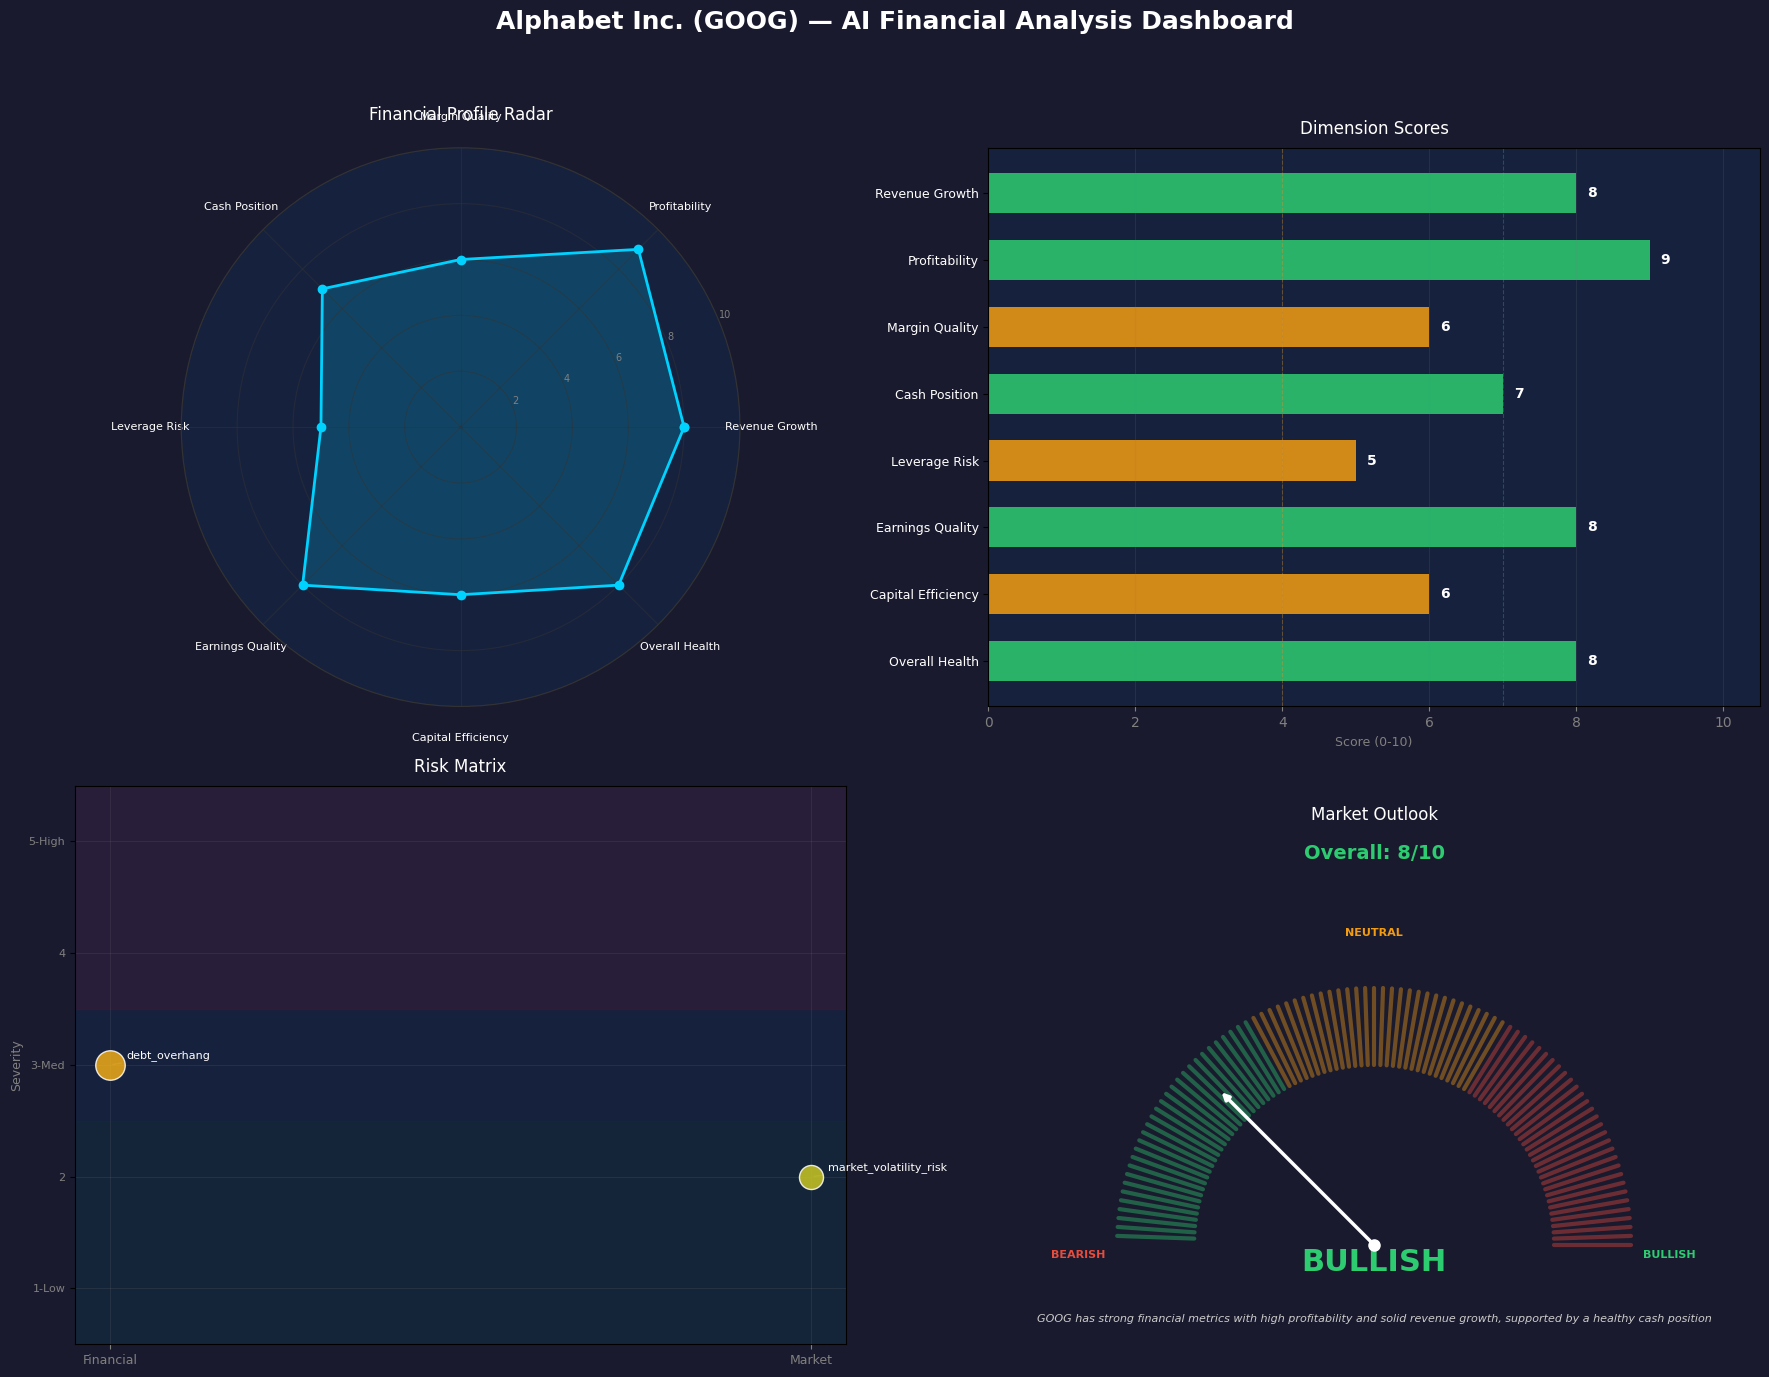


💾 Dashboard saved to /content/GOOG_ai_dashboard.png


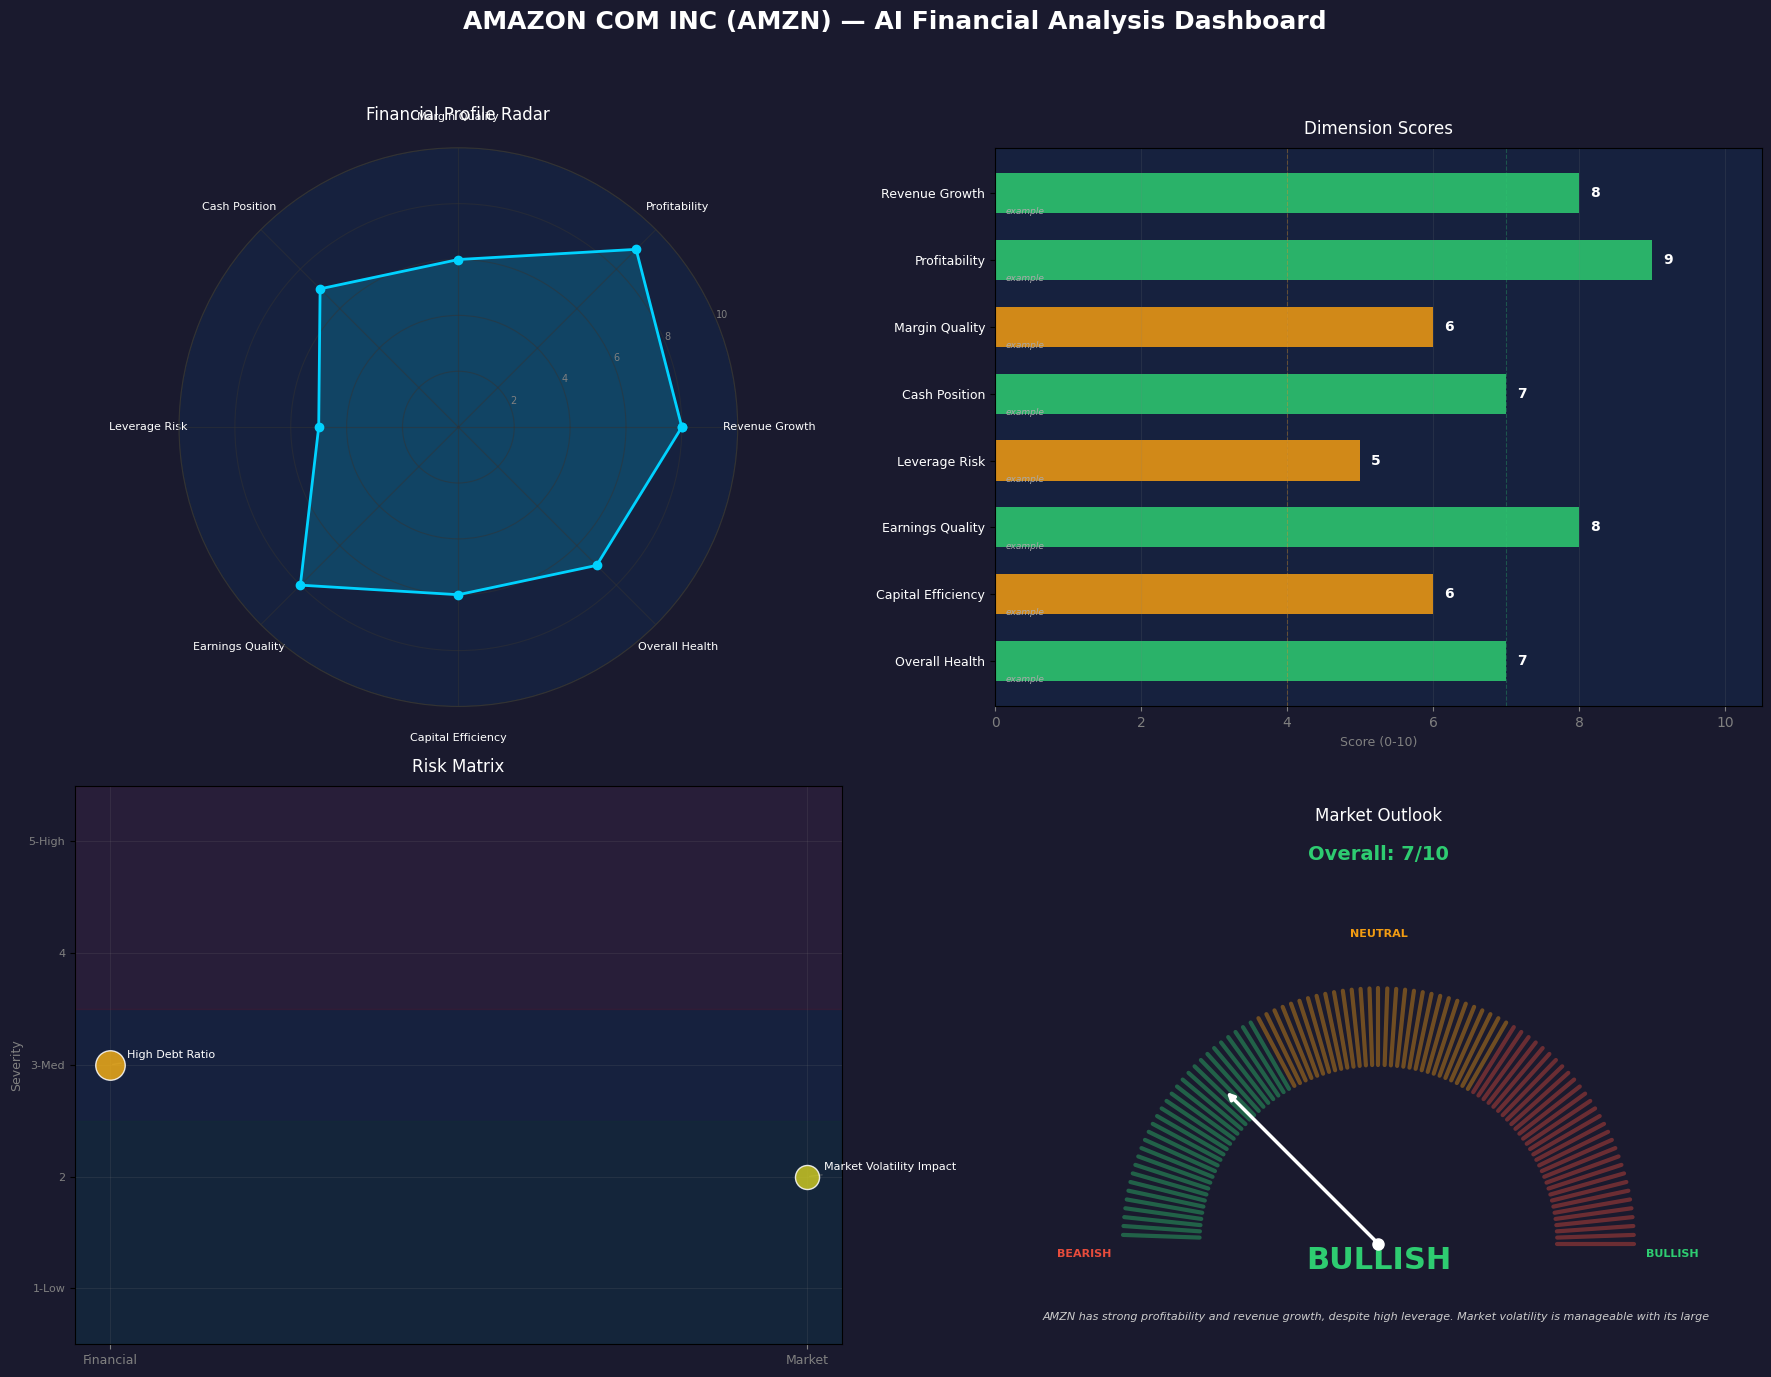


💾 Dashboard saved to /content/AMZN_ai_dashboard.png


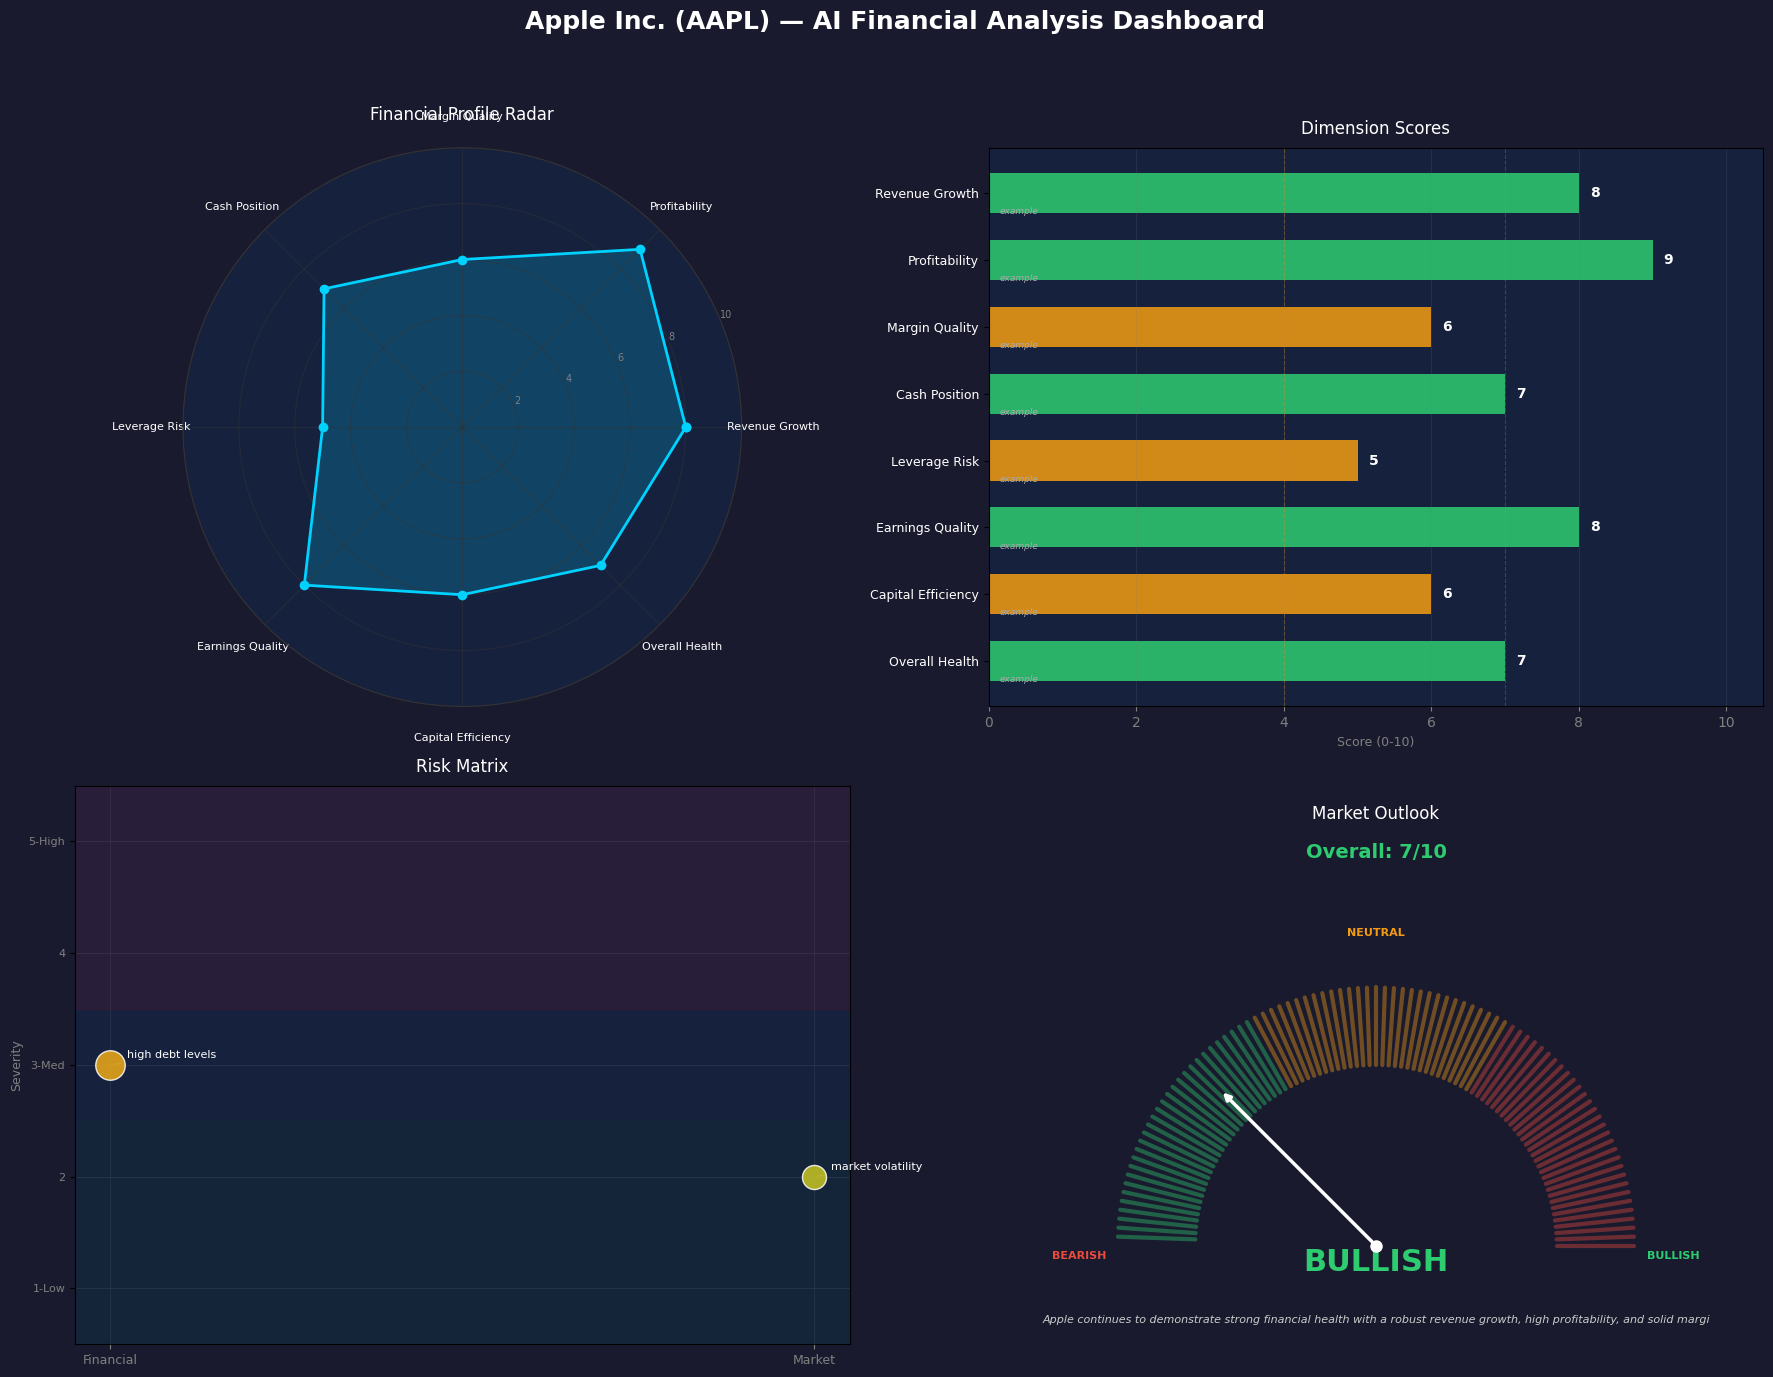


💾 Dashboard saved to /content/AAPL_ai_dashboard.png


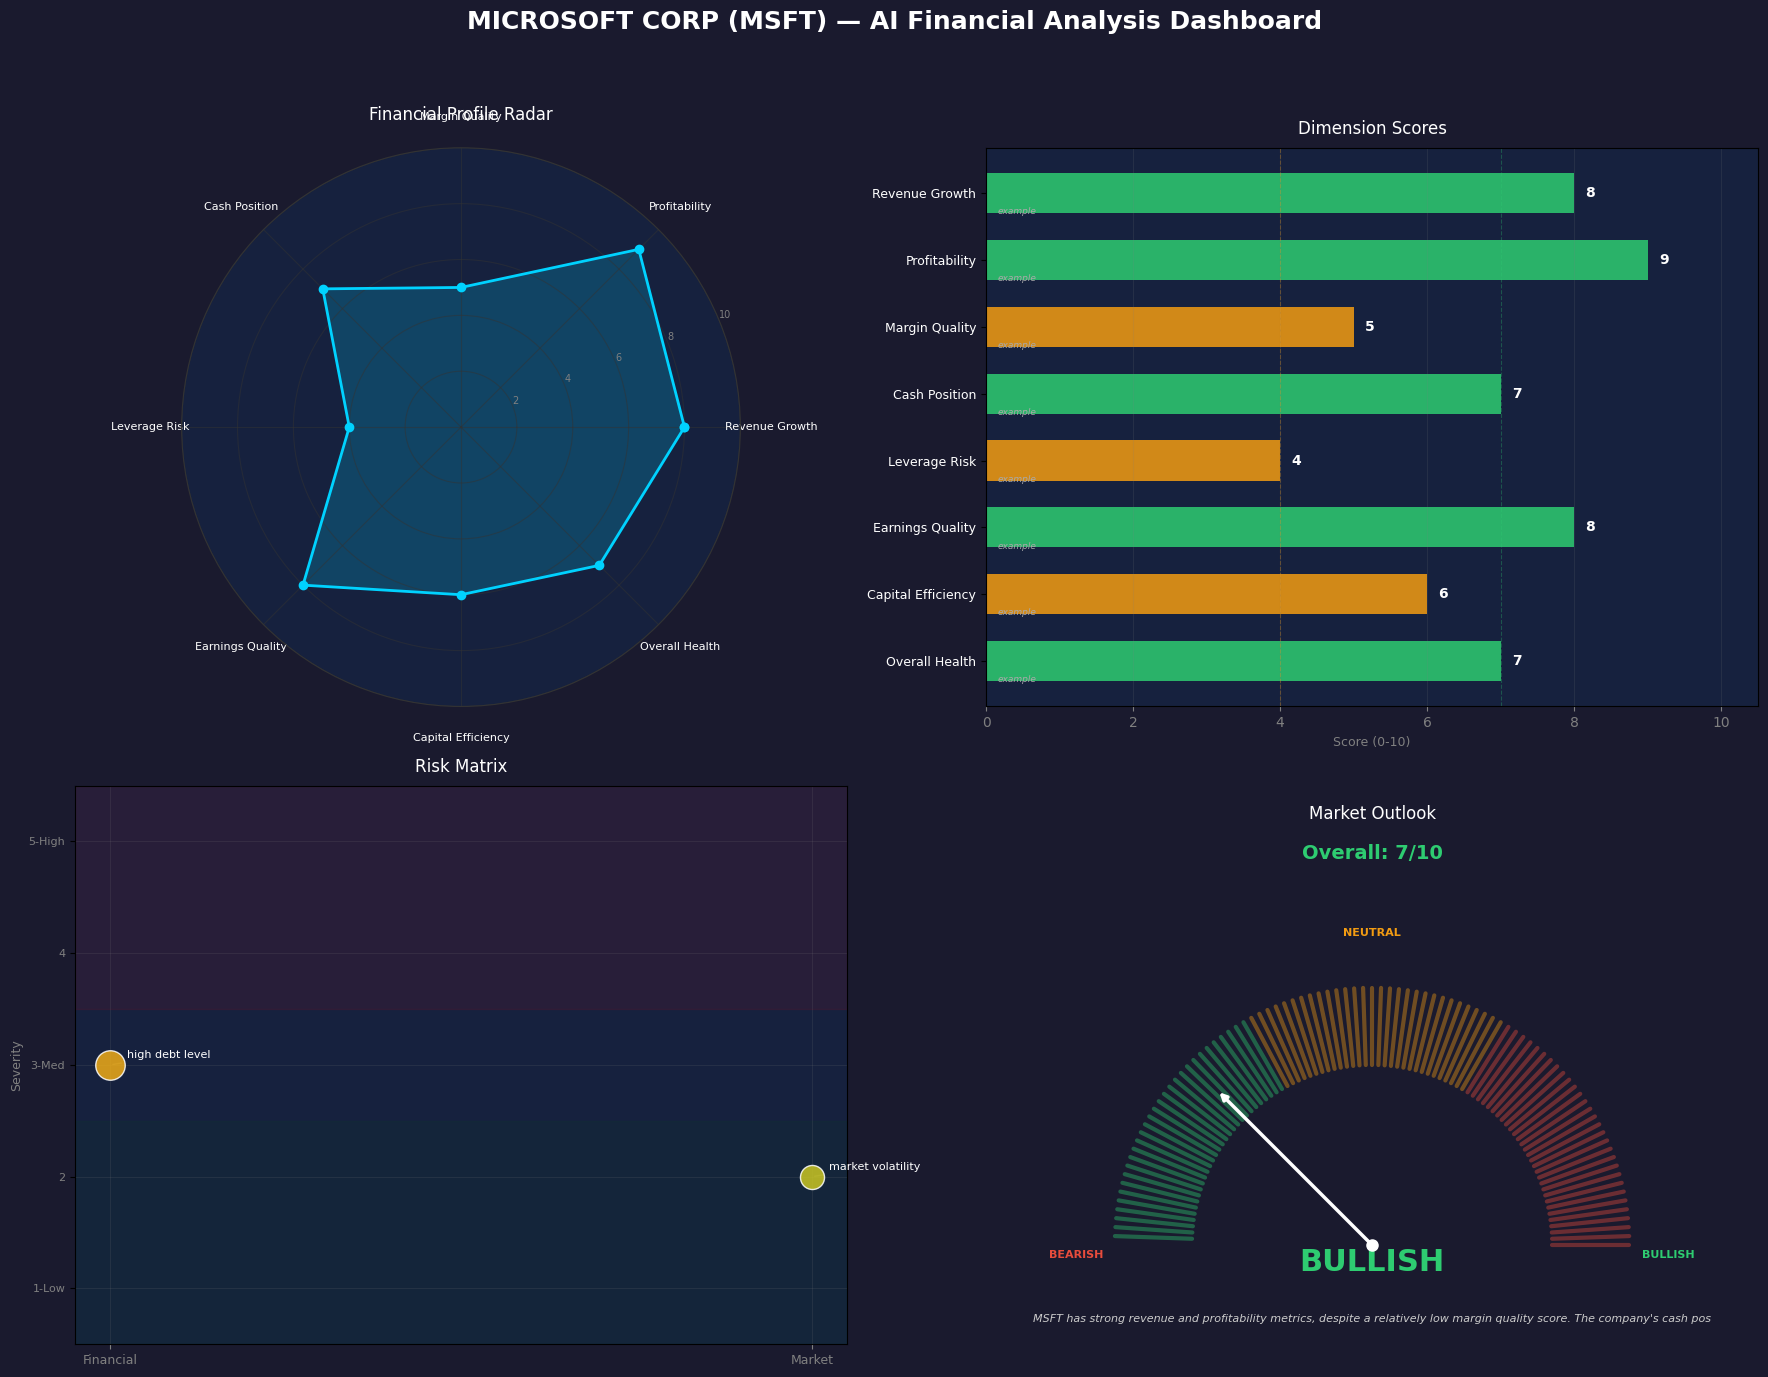


💾 Dashboard saved to /content/MSFT_ai_dashboard.png


In [ ]:
# ── Generate individual dashboards for each company ───────────────
print(f"📊 Rendering {len(all_scorecards)} individual dashboards...\n")
for tk, sc in all_scorecards.items():
    name = all_company_data[tk]["name"]
    render_dashboard(sc, name, tk)

### Comparison Dashboard

Side-by-side comparison across all analyzed companies — radar overlay, ranked scores, risk landscape, and head-to-head summary table.

/tmp/ipykernel_406/2075567854.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


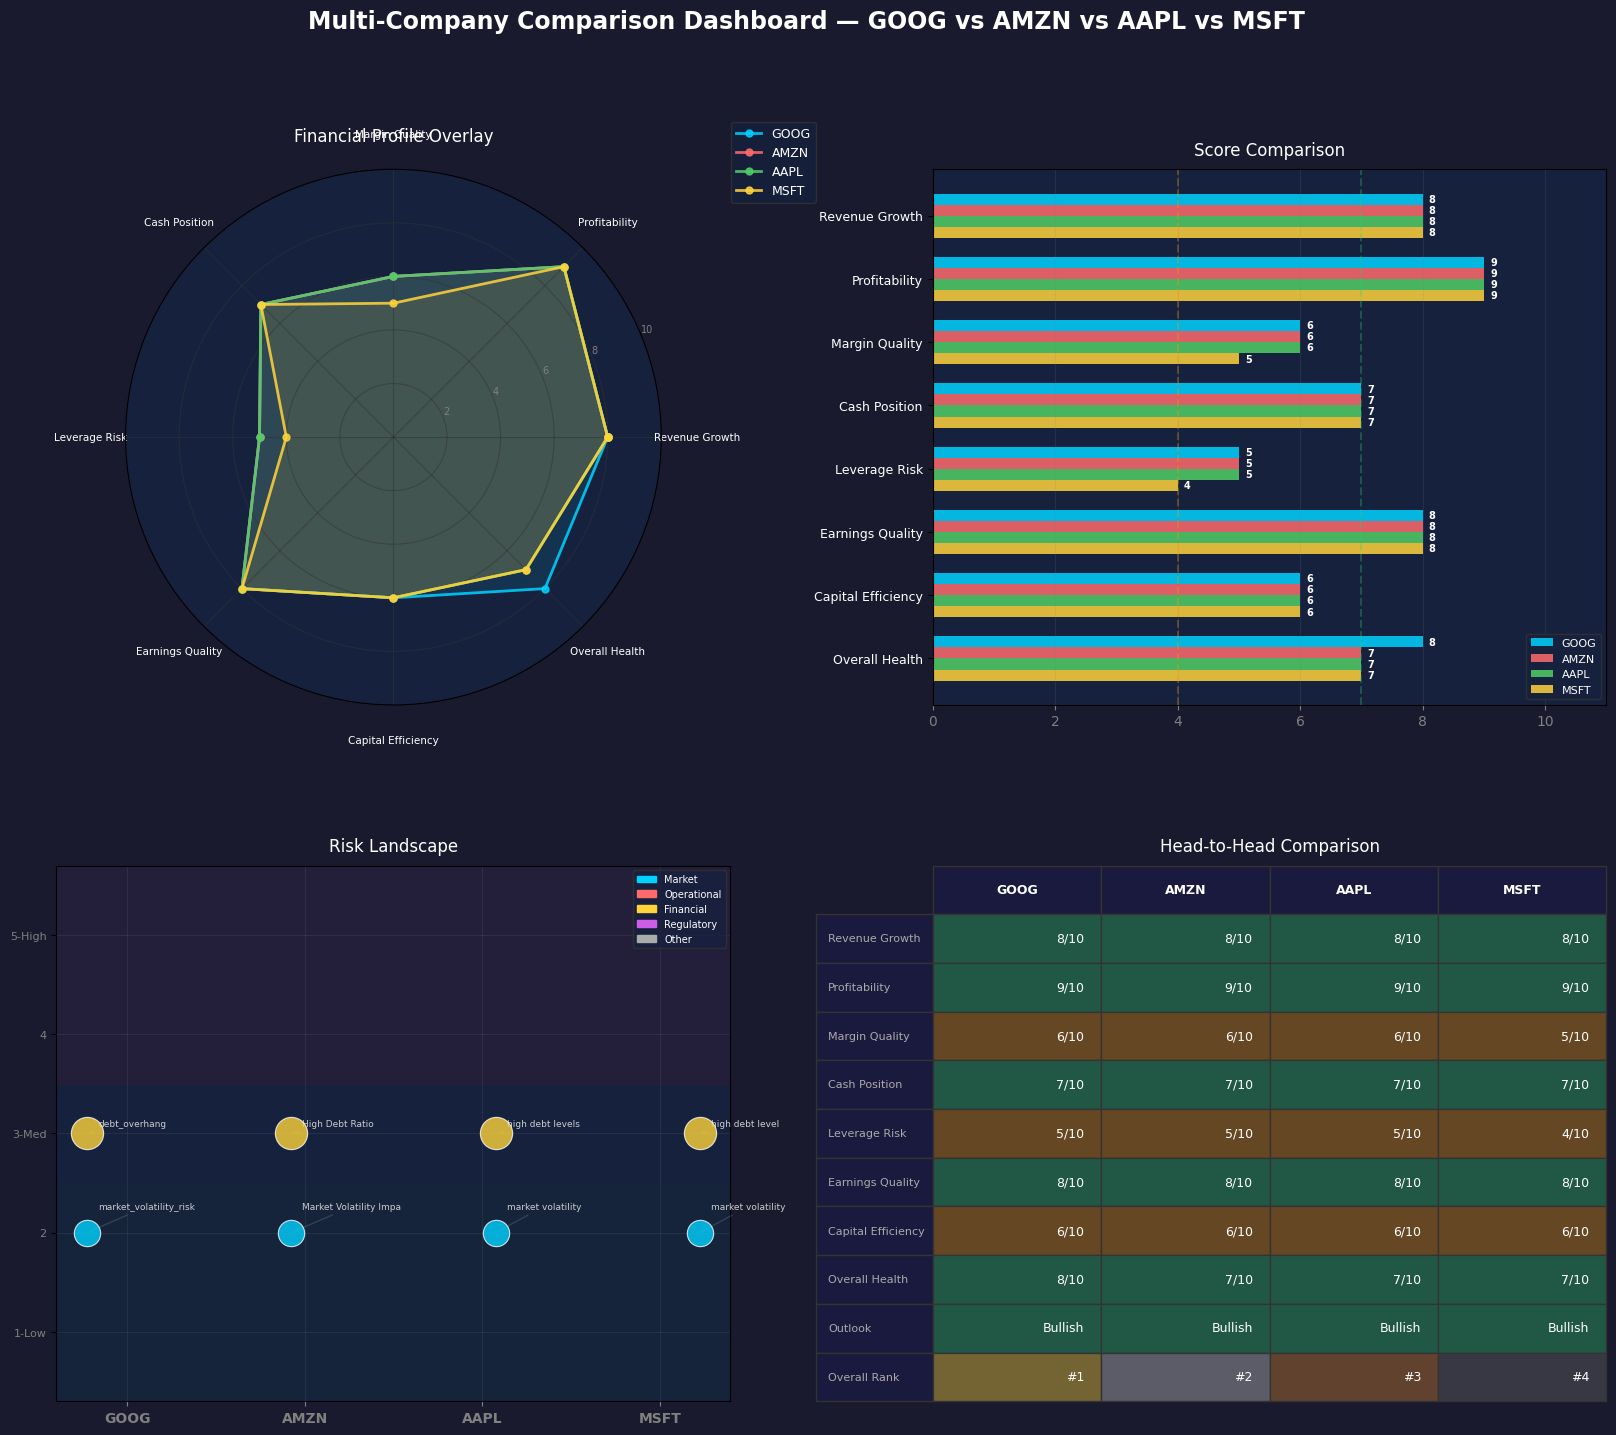


💾 Comparison dashboard saved to /content/comparison_dashboard.png
🏆 Top ranked: GOOG (Alphabet Inc.) — Overall: 8/10


In [ ]:
import itertools
import matplotlib.colors as mcolors

COMPANY_PALETTE = ["#00d2ff", "#ff6b6b", "#51cf66", "#ffd43b",
                   "#cc5de8", "#ff922b", "#20c997", "#da77f2"]
RISK_CAT_COLORS = {"market": "#00d2ff", "operational": "#ff6b6b",
                   "financial": "#ffd43b", "regulatory": "#cc5de8", "other": "#aaa"}

SCORE_DIMS = ["revenue_growth", "profitability", "margin_quality", "cash_position",
              "leverage_risk", "earnings_quality", "capital_efficiency", "overall_health"]
DIM_LABELS = [d.replace("_", " ").title() for d in SCORE_DIMS]


def render_comparison_dashboard(scorecards: dict, company_data: dict):
    """Render a 4-panel comparison dashboard across multiple companies."""
    tickers = list(scorecards.keys())
    n_companies = len(tickers)
    colors = dict(zip(tickers, itertools.islice(itertools.cycle(COMPANY_PALETTE), n_companies)))

    fig = plt.figure(figsize=(20, 16))
    fig.patch.set_facecolor("#1a1a2e")
    names = [company_data[t]["name"] for t in tickers]
    fig.suptitle("Multi-Company Comparison Dashboard — " + " vs ".join(tickers),
                 fontsize=17, fontweight="bold", color="white", y=0.98)

    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # ── PANEL 1: Radar Overlay ────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0], polar=True)
    ax1.set_facecolor("#16213e")

    N = len(SCORE_DIMS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles_closed = angles + [angles[0]]

    for tk in tickers:
        vals = [scorecards[tk]["scores"].get(d, {}).get("score", 5) for d in SCORE_DIMS]
        vals_closed = vals + [vals[0]]
        ax1.plot(angles_closed, vals_closed, "o-", linewidth=2, color=colors[tk],
                 markersize=5, label=tk, alpha=0.85)
        ax1.fill(angles_closed, vals_closed, alpha=0.1, color=colors[tk])

    ax1.set_xticks(angles)
    ax1.set_xticklabels(DIM_LABELS, fontsize=7.5, color="white")
    ax1.set_ylim(0, 10)
    ax1.set_yticks([2, 4, 6, 8, 10])
    ax1.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=7, color="gray")
    ax1.tick_params(axis="x", pad=15)
    ax1.grid(color="#333", alpha=0.5)
    ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9,
               facecolor="#16213e", edgecolor="#333", labelcolor="white")
    ax1.set_title("Financial Profile Overlay", fontsize=12, color="white", pad=20)

    # ── PANEL 2: Grouped Score Bars ───────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor("#16213e")

    bar_h = 0.7 / n_companies
    y_base = np.arange(N)

    for idx, tk in enumerate(tickers):
        vals = [scorecards[tk]["scores"].get(d, {}).get("score", 5) for d in SCORE_DIMS]
        offset = (idx - (n_companies - 1) / 2) * bar_h
        ax2.barh(y_base + offset, vals, height=bar_h, color=colors[tk],
                 alpha=0.85, label=tk, edgecolor="none")
        for j, v in enumerate(vals):
            ax2.text(v + 0.1, y_base[j] + offset, f"{v:.0f}", va="center",
                     fontsize=7, color="white", fontweight="bold")

    ax2.set_yticks(y_base)
    ax2.set_yticklabels(DIM_LABELS, fontsize=9, color="white")
    ax2.set_xlim(0, 11)
    ax2.invert_yaxis()
    ax2.axvline(x=7, color="#2ecc71", linestyle="--", alpha=0.3)
    ax2.axvline(x=4, color="#f39c12", linestyle="--", alpha=0.3)
    ax2.grid(axis="x", alpha=0.15, color="gray")
    ax2.tick_params(axis="x", colors="gray")
    ax2.legend(loc="lower right", fontsize=8, facecolor="#16213e",
               edgecolor="#333", labelcolor="white")
    ax2.set_title("Score Comparison", fontsize=12, color="white", pad=10)

    # ── PANEL 3: Risk Landscape ───────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_facecolor("#16213e")

    for idx, tk in enumerate(tickers):
        risks = scorecards[tk].get("risks", [])
        for ri, risk in enumerate(risks):
            sev = risk.get("severity", 3)
            cat = risk.get("category", "other")
            jitter = (idx - (n_companies - 1) / 2) * 0.15
            cat_color = RISK_CAT_COLORS.get(cat, "#aaa")
            ax3.scatter(idx + jitter, sev, s=sev * 180, c=[cat_color],
                       alpha=0.8, edgecolors="white", linewidth=0.8, zorder=5)
            name_short = risk.get("name", "")[:22]
            ax3.annotate(name_short, (idx + jitter, sev),
                        textcoords="offset points", xytext=(8, 5 + ri * 12),
                        fontsize=6.5, color="#ccc",
                        arrowprops=dict(arrowstyle="-", color="gray", alpha=0.3))

    ax3.set_xticks(range(n_companies))
    ax3.set_xticklabels(tickers, fontsize=10, color="white", fontweight="bold")
    ax3.set_ylim(0.3, 5.7)
    ax3.set_yticks([1, 2, 3, 4, 5])
    ax3.set_yticklabels(["1-Low", "2", "3-Med", "4", "5-High"], fontsize=8, color="gray")
    ax3.axhspan(3.5, 5.7, alpha=0.06, color="red")
    ax3.axhspan(0.3, 2.5, alpha=0.04, color="green")
    ax3.grid(alpha=0.15, color="gray")
    ax3.tick_params(axis="x", colors="gray")

    # Category legend
    cat_patches = [mpatches.Patch(color=c, label=k.title()) for k, c in RISK_CAT_COLORS.items()]
    ax3.legend(handles=cat_patches, loc="upper right", fontsize=7,
              facecolor="#16213e", edgecolor="#333", labelcolor="white")
    ax3.set_title("Risk Landscape", fontsize=12, color="white", pad=10)

    # ── PANEL 4: Head-to-Head Table ───────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_facecolor("#16213e")
    ax4.axis("off")

    # Build table data
    col_labels = tickers
    row_labels = DIM_LABELS + ["Outlook", "Overall Rank"]

    cell_text = []
    cell_colors = []

    # Score rows
    for dim in SCORE_DIMS:
        row = []
        row_c = []
        for tk in tickers:
            s = scorecards[tk]["scores"].get(dim, {}).get("score", 5)
            row.append(f"{s:.0f}/10")
            base = mcolors.to_rgb(score_color(s))
            row_c.append((*base, 0.35))
        cell_text.append(row)
        cell_colors.append(row_c)

    # Outlook row
    outlook_row = []
    outlook_colors = []
    for tk in tickers:
        ol = scorecards[tk].get("outlook", "neutral").title()
        outlook_row.append(ol)
        oc = {"Bullish": "#2ecc71", "Bearish": "#e74c3c"}.get(ol, "#f39c12")
        base = mcolors.to_rgb(oc)
        outlook_colors.append((*base, 0.35))
    cell_text.append(outlook_row)
    cell_colors.append(outlook_colors)

    # Rank row
    overall_scores = {tk: scorecards[tk]["scores"].get("overall_health", {}).get("score", 5) for tk in tickers}
    ranked = sorted(overall_scores.items(), key=lambda x: x[1], reverse=True)
    rank_map = {tk: i + 1 for i, (tk, _) in enumerate(ranked)}
    rank_row = []
    rank_colors = []
    for tk in tickers:
        r = rank_map[tk]
        rank_row.append(f"#{r}")
        gold = "#ffd43b" if r == 1 else "#c0c0c0" if r == 2 else "#cd7f32" if r == 3 else "#666"
        base = mcolors.to_rgb(gold)
        rank_colors.append((*base, 0.4))
    cell_text.append(rank_row)
    cell_colors.append(rank_colors)

    table = ax4.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                      cellColours=cell_colors, loc="center", bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(9)

    # Style table
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#333")
        cell.set_text_props(color="white", fontweight="bold" if row == 0 else "normal")
        if row == 0:  # header
            cell.set_facecolor("#1a1a3e")
        if col == -1:  # row labels
            cell.set_facecolor("#1a1a3e")
            cell.set_text_props(color="#aaa", fontsize=8)

    ax4.set_title("Head-to-Head Comparison", fontsize=12, color="white", pad=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("/content/comparison_dashboard.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"\n💾 Comparison dashboard saved to /content/comparison_dashboard.png")

    # Print winner
    winner_tk = ranked[0][0]
    winner_score = ranked[0][1]
    print(f"🏆 Top ranked: {winner_tk} ({company_data[winner_tk]['name']}) — Overall: {winner_score:.0f}/10")


# ── Render comparison ─────────────────────────────────────────────
render_comparison_dashboard(all_scorecards, all_company_data)

---

## Full Pipeline Summary

| Phase | What | Parallelism | Time |
|-------|------|------------|------|
| **Data Fetch** | SEC EDGAR XBRL for all tickers | 4 workers | ~2s/company |
| **AI Scoring** | Ollama structured JSON analysis | 2 workers | ~4min/company |
| **Individual Dashboards** | 4-panel per company (radar, bars, risks, gauge) | Sequential render | ~1s each |
| **Comparison Dashboard** | Radar overlay + ranked bars + risk landscape + H2H table | Single render | ~1s |

**Artifacts produced:**
- `/content/{TICKER}_ai_dashboard.png` — per-company dashboard
- `/content/comparison_dashboard.png` — multi-company comparison

**To analyze different companies**, change `TICKERS` in section 15 and re-run from there.

---
*AI analysis powered by [Ollama](https://ollama.com) running locally. Data from [SEC EDGAR](https://www.sec.gov/edgar). No API keys. No data leaves the instance.*